In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

- 2013년이후 전국 아파트분양가격
- 공공데이터 포털에 있는 데이터를 Pandas의 melt, concat, transpose와 같은 reshape 기능을 활용해 분석
- groupby, pivot_table, info, describe, value_counts등을 통한 데이터 요약과 분석
- 이를 통해 전혀 다른 두 데이터의 정제와 병합, 수치형 데이터의 차이를 이해하고 다양한 그래프로 시각화(barplot, lineplot, scatterplot, lmplot, swarmplot, histplot)

# 1. 패키지로드 & 한글설정 & 경고메세지 ignore

In [156]:
# 패키지 import
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 시각화의 선명도를 높임
%config InlineBackend.figure_format = "retina"

# 다른 폰트를 기본으로 하려면
from matplotlib.font_manager import FontProperties, fontManager
font_path = r"C:\Users\Admin\Downloads\JMK체.ttf"
fontManager.addfont(font_path)
# 폰트 다운로드 : 네이버, 구글, 눈누, 산들 등에서 ttf 파일 
font_prop = FontProperties(fname=font_path, size=12)
font_name = font_prop.get_name()

# 한글설정
plt.rc('font', family=font_name)
plt.rc('font', size=12)
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

# warning(경고) 안보이게
import warnings
# warnings.filterwarnings(action='ignore')

# 2. 데이터 다운로드
- https://www.data.go.kr 에서 "아파트 분양 가격"을 검색 후 csv 다운로드

## (1) 2013년9월부터 2015년8월까지 데이터는 df_first 변수에 담아 탐색

In [2]:
df_first = pd.read_csv('c:/ai/downloads/shareData/분양가격/전국 평균 평당 분양가격(2013년 9월부터 2015년 8월까지).csv',
                      encoding='cp949')
df_first.head(1)

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,...,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
0,서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,...,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443


In [4]:
pd.options.display.max_columns = 22 # 최대 display가능한 열수 수정

In [9]:
df_first.sample()

,지역,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,2014년10월,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
15,경남,6473,6485,6502,6610,6599,6610,6615,6613,6606,6767,6881,7125,7332,7592,7588,7668,7683,7717,7715,7723,7665


In [10]:
df_first.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   지역        17 non-null     object
 1   2013년12월  17 non-null     int64 
 2   2014년1월   17 non-null     int64 
 3   2014년2월   17 non-null     int64 
 4   2014년3월   17 non-null     int64 
 5   2014년4월   17 non-null     int64 
 6   2014년5월   17 non-null     int64 
 7   2014년6월   17 non-null     int64 
 8   2014년7월   17 non-null     int64 
 9   2014년8월   17 non-null     int64 
 10  2014년9월   17 non-null     int64 
 11  2014년10월  17 non-null     int64 
 12  2014년11월  17 non-null     int64 
 13  2014년12월  17 non-null     int64 
 14  2015년1월   17 non-null     int64 
 15  2015년2월   17 non-null     int64 
 16  2015년3월   17 non-null     int64 
 17  2015년4월   17 non-null     int64 
 18  2015년5월   17 non-null     int64 
 19  2015년6월   17 non-null     int64 
 20  2015년7월   17 non-null     int64 
 21  2015년8월   17 non-n

In [5]:
df_first.set_index('지역', inplace=True)
df_first

,2013년12월,2014년1월,2014년2월,2014년3월,2014년4월,2014년5월,2014년6월,2014년7월,2014년8월,2014년9월,2014년10월,2014년11월,2014년12월,2015년1월,2015년2월,2015년3월,2015년4월,2015년5월,2015년6월,2015년7월,2015년8월
지역,,,,,,,,,,,,,,,,,,,,,
서울,18189,17925,17925,18016,18098,19446,18867,18742,19274,19404,19759,20242,20269,20670,20670,19415,18842,18367,18374,18152,18443
부산,8111,8111,9078,8965,9402,9501,9453,9457,9411,9258,9110,9208,9208,9204,9235,9279,9327,9345,9515,9559,9581
대구,8080,8080,8077,8101,8267,8274,8360,8360,8370,8449,8403,8439,8253,8327,8416,8441,8446,8568,8542,8542,8795
인천,10204,10204,10408,10408,10000,9844,10058,9974,9973,9973,10016,10020,10020,10017,9876,9876,9938,10551,10443,10443,10449
광주,6098,7326,7611,7346,7346,7523,7659,7612,7622,7802,7707,7752,7748,7752,7756,7861,7914,7877,7881,8089,8231
대전,8321,8321,8321,8341,8341,8341,8333,8333,8333,8048,8038,8067,8067,8067,8067,8067,8145,8272,8079,8079,8079
울산,8090,8090,8090,8153,8153,8153,8153,8153,8493,8493,8627,8891,8891,8526,8526,8629,9380,9192,9190,9190,9215
경기,10855,10855,10791,10784,10876,10646,10266,10124,10134,10501,10397,10356,10379,10391,10355,10469,10684,10685,10573,10518,10573
세종,7601,7600,7532,7814,7908,7934,8067,8067,8141,8282,8527,8592,8560,8560,8560,8555,8546,8546,8671,8669,8695


- color map 참조 : https://matplotlib.org/stable/users/explain/colors/colormaps.html

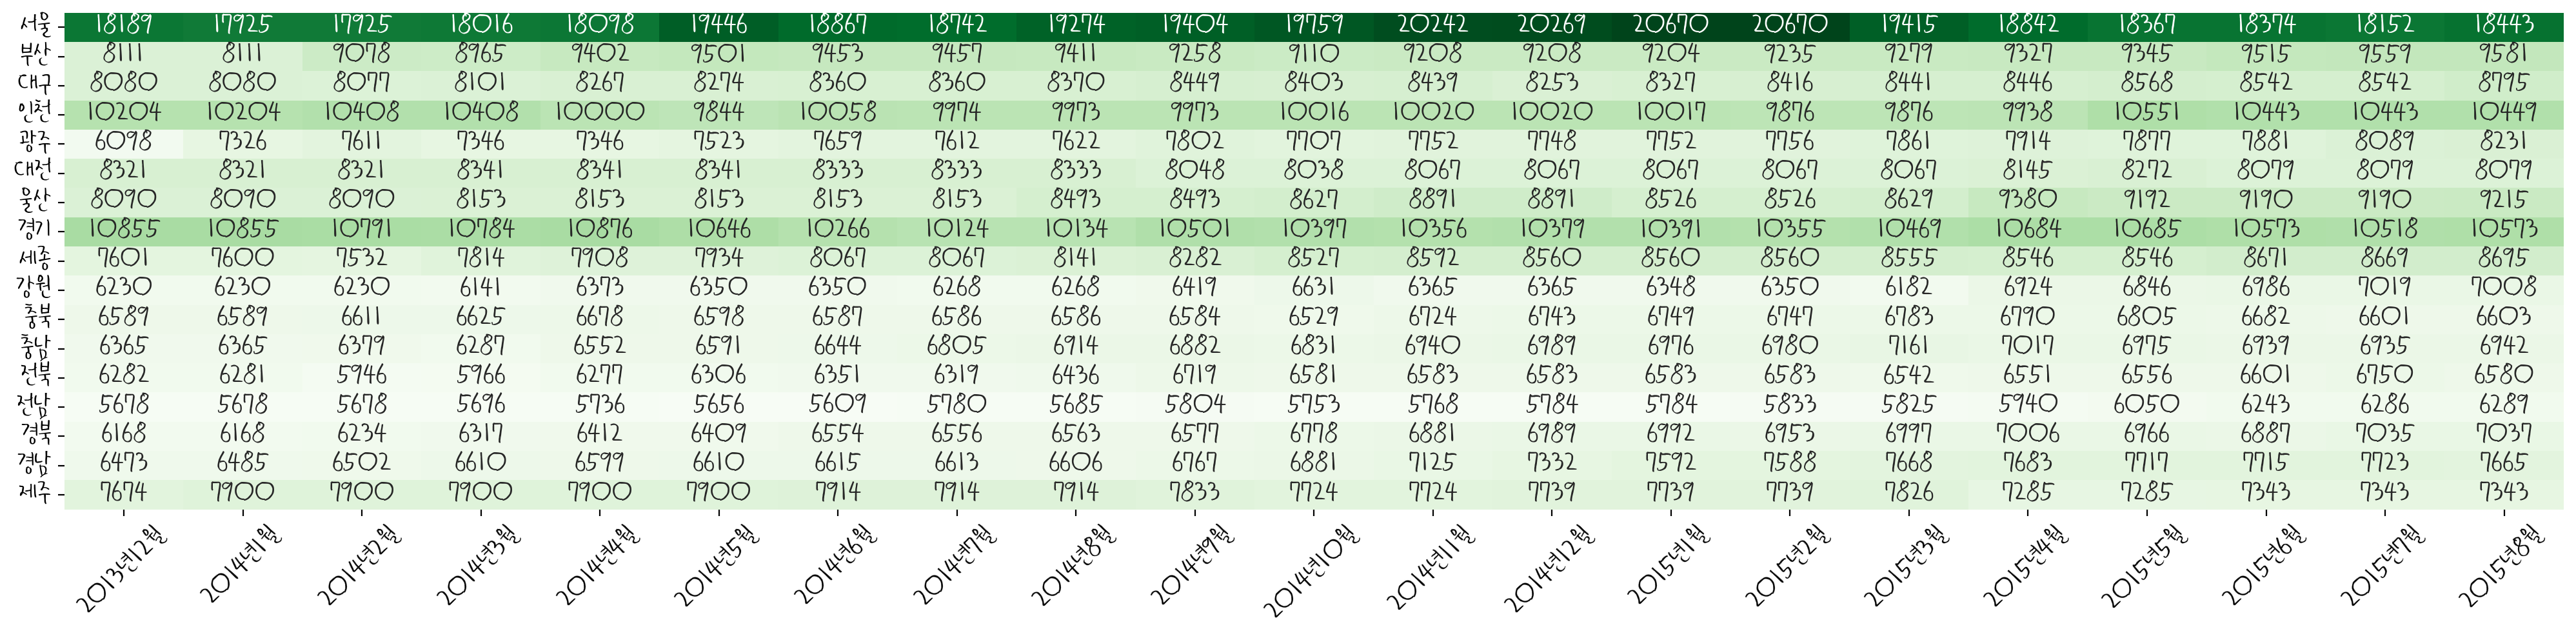

In [12]:
plt.figure(figsize=(25, 5))
sns.heatmap(df_first, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.xticks(rotation=45)
plt.ylabel(None)
plt.show()

## (2) 이후 데이터는 df_last 변수에 담아 탐색

In [6]:
df_last = pd.read_csv('c:/ai/downloads/shareData/분양가격/주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20260531 (1).csv',
                     encoding='cp949')
df_last.shape

(10880, 5)

In [16]:
df_last.tail(3)

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
10877,제주,전용면적 60제곱미터초과 85제곱미터이하,2026,5,4485
10878,제주,전용면적 85제곱미터초과 102제곱미터이하,2026,5,NaN
10879,제주,전용면적 102제곱미터초과,2026,5,4350


In [17]:
# 데이터 요약하기
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   지역명             10880 non-null  object
 1   규모구분            10880 non-null  object
 2   연도              10880 non-null  int64 
 3   월               10880 non-null  int64 
 4   분양가격(제곱미터당 천원)  10035 non-null  object
dtypes: int64(2), object(3)
memory usage: 425.1+ KB


In [18]:
df_last['분양가격(제곱미터당 천원)'].describe()

count     10035
unique     3637
top            
freq         95
Name: 분양가격(제곱미터당 천원), dtype: object

# 3. df_last의 데이터 결측치를 확인하고 대체 고민

In [8]:
# 열별 결측치 갯수
df_last.isna().sum()

지역명                 0
규모구분                0
연도                  0
월                   0
분양가격(제곱미터당 천원)    845
dtype: int64

In [10]:
# 결측치인 행
df_last[df_last['분양가격(제곱미터당 천원)'].isna()]

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
368,광주,전용면적 85제곱미터초과 102제곱미터이하,2016,2,NaN
369,광주,전용면적 102제곱미터초과,2016,2,NaN
374,대전,전용면적 102제곱미터초과,2016,2,NaN
388,강원,전용면적 85제곱미터초과 102제곱미터이하,2016,2,NaN
421,제주,전용면적 60제곱미터이하,2016,2,NaN
...,...,...,...,...,...
10839,세종,전용면적 102제곱미터초과,2026,5,NaN
10858,전북,전용면적 85제곱미터초과 102제곱미터이하,2026,5,NaN
10863,전남,전용면적 85제곱미터초과 102제곱미터이하,2026,5,NaN
10876,제주,전용면적 60제곱미터이하,2026,5,NaN


In [9]:
# 열별 결측치를 제외한 갯수
df_last.count()

지역명               10880
규모구분              10880
연도                10880
월                 10880
분양가격(제곱미터당 천원)    10035
dtype: int64

# 4. df_last 데이셋에 평당분양가격컬럼 추가

## (1) astype('float')나 pd.to_numeric() 사용
## (2) 6,222 => 6222 수정 후, 형변환
## (3) df_last['분양가격(제곱미터)']*3.3

In [15]:
# df_last['분양가격(제곱미터당 천원)'].astype('float64') - '  ' 존재로 astype 에러 발생
pd.to_numeric(df_last['분양가격(제곱미터당 천원)'], errors='coerce')
# 변경 후 결측치 개수 973 = 원본 NaN 845 + ' ','  ',etc 128

973

In [19]:
# '분양가격(제곱미터당 천원)' = ' ','  '인 행 126 >>> 128 중 ' ', '  '가 아닌 요소 2개
df_last[df_last['분양가격(제곱미터당 천원)'].str.strip()=='']

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
28,광주,전용면적 85제곱미터초과 102제곱미터이하,2015,10,
29,광주,전용면적 102제곱미터초과,2015,10,
34,대전,전용면적 102제곱미터초과,2015,10,
81,제주,전용면적 60제곱미터이하,2015,10,
113,광주,전용면적 85제곱미터초과 102제곱미터이하,2015,11,
...,...,...,...,...,...
8833,경남,전용면적 85제곱미터초과 102제곱미터이하,2024,5,
8836,제주,전용면적 60제곱미터이하,2024,5,
8838,제주,전용면적 85제곱미터초과 102제곱미터이하,2024,5,
8964,울산,전용면적 102제곱미터초과,2024,7,


In [21]:
# '분양가격(제곱미터당 천원)'의 요소 종류 파악 (5,000 형식의 데이터 있는지 확인)
temp = pd.to_numeric(df_last['분양가격(제곱미터당 천원)'], errors='coerㅠce')
nanidx = temp[temp.isna()].index
df_last.loc[nanidx, '분양가격(제곱미터당 천원)'].unique()

array(['  ', nan, ' ', '-'], dtype=object)

In [22]:
# '분양가격(제곱미터당 천원)' = '-'인 행 2
df_last[df_last['분양가격(제곱미터당 천원)'].str.strip()=='-']

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원)
8861,대구,전용면적 60제곱미터이하,2024,6,-
8863,대구,전용면적 85제곱미터초과 102제곱미터이하,2024,6,-


### apply

In [25]:
# 콤마가 있는 문자에서 콤마를 없애는 방법
temp = '5,000'
temp.replace(',','')

'5000'

In [27]:
# nan >>> nan , ' ' >>> nan, '-' >>> nan, '숫자' >>> 숫자
def commadrop(row):
    row = row.copy()
    price = row['분양가격(제곱미터당 천원)']
    
    if pd.isna(price):
        row['분양가격(제곱미터당 천원)'] = np.nan
        
    elif price.strip() == '' or price == '-':
        row['분양가격(제곱미터당 천원)'] = np.nan
        
    elif price.find(',') != -1:
        row['분양가격(제곱미터당 천원)'] = float(price.replace(',',''))
        
    else:
        row['분양가격(제곱미터당 천원)'] = float(price)
        
    return row
        
print(commadrop(df_last.loc[0])) # '숫자' >>> 숫자
print(commadrop(df_last.loc[28])) # ' ' >>> nan
print(commadrop(df_last.loc[368])) # nan >>> nan
print(commadrop(df_last.loc[8863])) # '-' >>> nan

지역명                   서울
규모구분                모든면적
연도                  2015
월                     10
분양가격(제곱미터당 천원)    5841.0
Name: 0, dtype: object
지역명                                    광주
규모구분              전용면적 85제곱미터초과 102제곱미터이하
연도                                   2015
월                                      10
분양가격(제곱미터당 천원)                        NaN
Name: 28, dtype: object
지역명                                    광주
규모구분              전용면적 85제곱미터초과 102제곱미터이하
연도                                   2016
월                                       2
분양가격(제곱미터당 천원)                        NaN
Name: 368, dtype: object
지역명                                    대구
규모구분              전용면적 85제곱미터초과 102제곱미터이하
연도                                   2024
월                                       6
분양가격(제곱미터당 천원)                        NaN
Name: 8863, dtype: object


In [29]:
# 공백문자는 결측치로, 콤마 제거하기를 모든 행에 적용
df_last = df_last.apply(commadrop, axis=1)

In [30]:
df_last['분양가격(제곱미터당 천원)'].isna().sum()

973

### map

In [34]:
df_last = pd.read_csv('c:/ai/downloads/shareData/분양가격/주택도시보증공사_전국 신규 민간아파트 분양가격 동향_20260531 (1).csv',
                     encoding='cp949')

In [35]:
# nan >>> nan , ' ' >>> nan, '-' >>> nan, '숫자' >>> 숫자, '숫,자' >>> 숫자
def commadrop2(price):
    if pd.isna(price):
        return np.nan
        
    elif price.strip() == '' or price == '-':
        return np.nan
        
    elif price.find(',') != -1:
        return float(price.replace(',',''))
        
    else:
        return float(price)
        
print(commadrop2(df_last.loc[0, '분양가격(제곱미터당 천원)'])) # '숫자' >>> 숫자
print(commadrop2(df_last.loc[28, '분양가격(제곱미터당 천원)'])) # ' ' >>> nan
print(commadrop2(df_last.loc[368, '분양가격(제곱미터당 천원)'])) # nan >>> nan
print(commadrop2(df_last.loc[8863, '분양가격(제곱미터당 천원)'])) # '-' >>> nan

5841.0
nan
nan
nan


- apply(함수, axis) : 1차원, 2차원(axis 지정, axis 기본값 : 0)
- map(함수) : 1차원
- applymap(함수) : 2차원(모든 요소에 함수 적용)

In [39]:
#df_last['분양가격(제곱미터당 천원)'].apply(commadrop2)
df_last['제곱미터당 분양가격'] = df_last['분양가격(제곱미터당 천원)'].map(commadrop2)
df_last.iloc[8863:8866]

,지역명,규모구분,연도,월,분양가격(제곱미터당 천원),제곱미터당 분양가격
8863,대구,전용면적 85제곱미터초과 102제곱미터이하,2024,6,-,NaN
8864,대구,전용면적 102제곱미터초과,2024,6,5593,5593.0
8865,광주,모든면적,2024,6,5471,5471.0


### apply/map 사용 않고 적용하기

In [41]:
pd.to_numeric(df_last['분양가격(제곱미터당 천원)'].str.replace(',',''), errors='coerce')

0        5841.0
1        5652.0
2        5882.0
3        5721.0
4        5879.0
          ...  
10875    4473.0
10876       NaN
10877    4485.0
10878       NaN
10879    4350.0
Name: 분양가격(제곱미터당 천원), Length: 10880, dtype: float64

In [43]:
df_last['제곱미터당 분양가격'] = pd.to_numeric(df_last['분양가격(제곱미터당 천원)'].str.replace(',',''), errors='coerce')
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   지역명             10880 non-null  object 
 1   규모구분            10880 non-null  object 
 2   연도              10880 non-null  int64  
 3   월               10880 non-null  int64  
 4   분양가격(제곱미터당 천원)  10035 non-null  object 
 5   제곱미터당 분양가격      9907 non-null   float64
dtypes: float64(1), int64(2), object(3)
memory usage: 510.1+ KB


In [44]:
df_last['평당 분양가격'] = df_last['제곱미터당 분양가격'] * 3.3
df_last.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10880 entries, 0 to 10879
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   지역명             10880 non-null  object 
 1   규모구분            10880 non-null  object 
 2   연도              10880 non-null  int64  
 3   월               10880 non-null  int64  
 4   분양가격(제곱미터당 천원)  10035 non-null  object 
 5   제곱미터당 분양가격      9907 non-null   float64
 6   평당 분양가격         9907 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 595.1+ KB


In [45]:
df_last[['제곱미터당 분양가격', '평당 분양가격']].describe()

,제곱미터당 분양가격,평당 분양가격
count,9907.000000,9907.000000
mean,4291.544867,14162.098062
std,2125.581720,7014.419675
min,1868.000000,6164.400000
25%,2872.000000,9477.600000
50%,3798.000000,12533.400000
75%,4940.500000,16303.650000
max,22713.000000,74952.900000


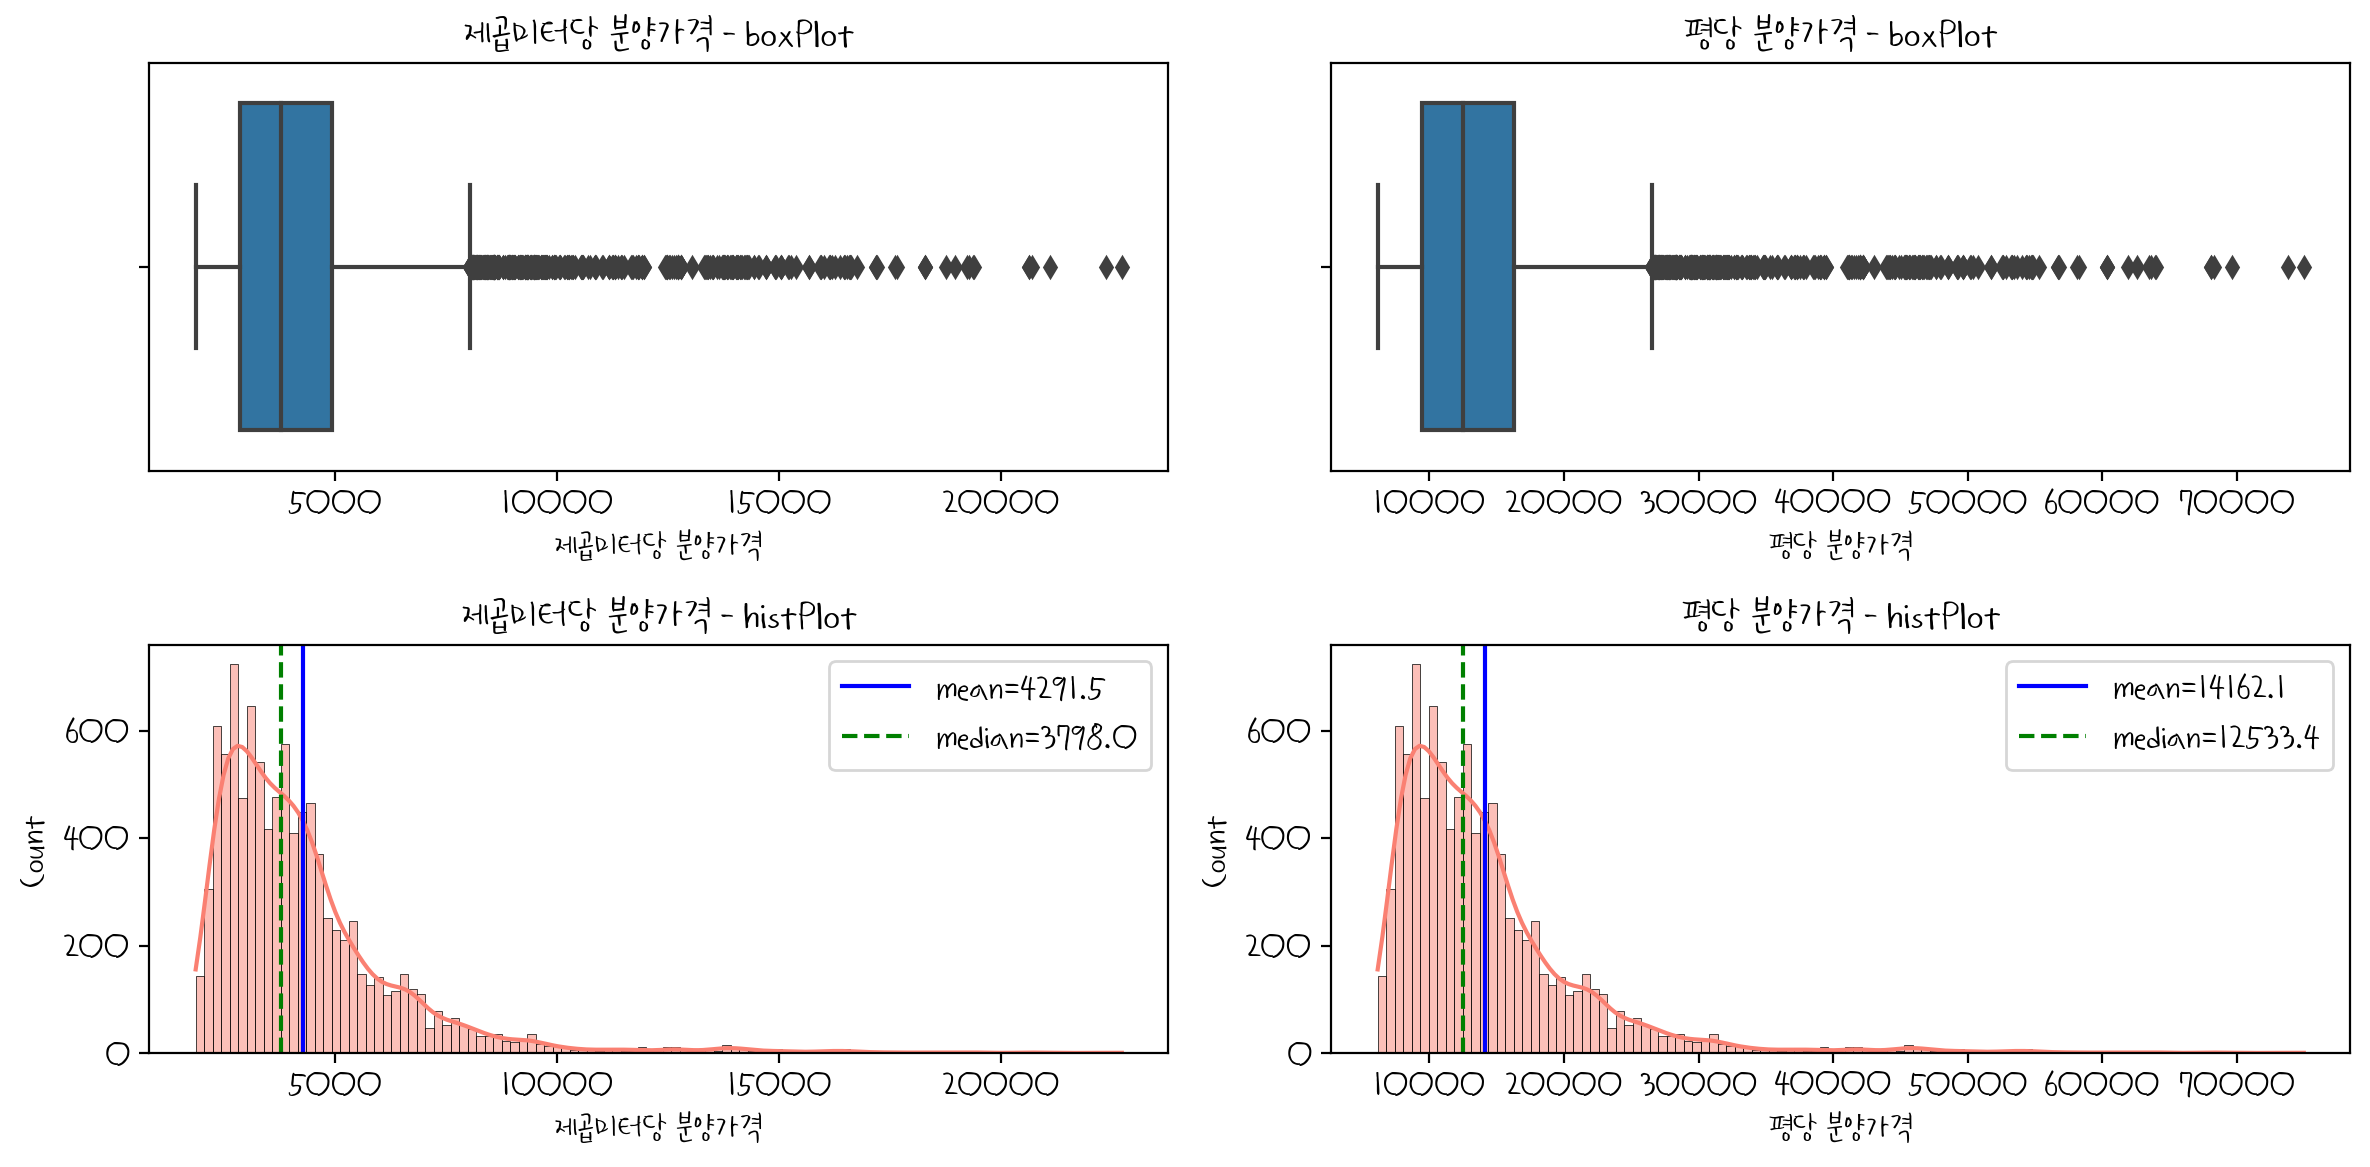

In [59]:
cols = ['제곱미터당 분양가격', '평당 분양가격']
fig, axes = plt.subplots(nrows=2, ncols=len(cols), figsize=(12, 6))

plt.subplots_adjust(hspace=0.6, wspace=0.2)

for i, col in enumerate(cols):
    sns.boxplot(data=df_last, x=col, ax = axes[0, i])
    axes[0,i].set_title(f'{col} - boxPlot')
    sns.histplot(data=df_last, x = col, ax = axes[1, i], color='salmon', kde=True)
    axes[1,i].set_title(f'{col} - histPlot')
    axes[1,i].axvline(df_last[col].mean(), c='b', linestyle='-', label=f'mean={df_last[col].mean():.1f}')
    axes[1,i].axvline(df_last[col].median(), c='g', linestyle='--', label=f'median={df_last[col].median():.1f}')
    axes[1,i].legend()

plt.tight_layout()

In [60]:
# 왜도(skewness) skew : 분포의 비대칭 정도를 수치로 나타내는 지표
    # 0 : 좌우 대칭 / |skew| < 0.5 : 대칭성 높음
    # skew > 0 : 오른쪽 꼬리 긴 분포 (평균 > 중위수)
    # skew < 0 : 왼쪽 꼬리 긴 분포 (중위수 < 평균)
    
df_last[['제곱미터당 분양가격', '평당 분양가격']].skew()

제곱미터당 분양가격    2.582328
평당 분양가격       2.582328
dtype: float64

# 5. df_last 데이터셋에서 전용면적 컬럼을 추가한다
- 전용면적 컬럼, 필요없는 컬럼 처리로 메모리 절약

In [62]:
df_last['규모구분'].unique()

array(['모든면적', '전용면적 60제곱미터이하', '전용면적 60제곱미터초과 85제곱미터이하',
       '전용면적 85제곱미터초과 102제곱미터이하', '전용면적 102제곱미터초과'], dtype=object)

In [78]:
# 전용면적 60제곱미터이하 >>> 60m²
# 전용면적 60제곱미터초과 85제곱미터이하 >>> 60m²~85m²
# 전용면적 102제곱미터초과 >>> 102m²~

df_last['전용면적'] = df_last['규모구분'].str.replace('전용면적','').str.replace('이하','').str.replace('제곱미터','m²').str.replace(' ','').str.replace('초과','~ ')

In [79]:
print(df_last['전용면적'].unique())
print(df_last['규모구분'].unique())

['모든면적' '60m²' '60m²~ 85m²' '85m²~ 102m²' '102m²~ ']
['모든면적' '전용면적 60제곱미터이하' '전용면적 60제곱미터초과 85제곱미터이하' '전용면적 85제곱미터초과 102제곱미터이하'
 '전용면적 102제곱미터초과']


# 6. 메모리 사용량을 줄이기 위해 불필요한 컬럼 제거

In [82]:
df_last.drop(['규모구분', '분양가격(제곱미터당 천원)', '제곱미터당 분양가격'], axis=1, inplace=True)

In [86]:
# 열 순서 변경하기

# df_last[['지역명','전용면적','연도','월','평당 분양가격']]
# df_last.reindex(columns=['지역명','전용면적','연도','월','평당 분양가격'])
col = df_last.pop('전용면적')
df_last.insert(1, '전용면적', col)

In [87]:
df_last.head()

,지역명,전용면적,연도,월,평당 분양가격
0,서울,모든면적,2015,10,19275.3
1,서울,60m²,2015,10,18651.6
2,서울,60m²~ 85m²,2015,10,19410.6
3,서울,85m²~ 102m²,2015,10,18879.3
4,서울,102m²~,2015,10,19400.7


# df_last 저장 위치

In [88]:
df_last.to_csv('data/df_last.csv', index=False) # 전처리 단계 백업

In [3]:
df_last = pd.read_csv('data/df_last.csv')

# 7. 데이터 집계
- GroupBy(unstack()함수 이용) vs. pivot_table()
- GroupBy가 시간 소요에서 이득인 부분이 있음
- 결측치 대체 전 데이터의 집계와 시각화

```
- df_last.groupby(["인덱스로 사용할 컬럼명"])["계산할 컬럼명"].연산함수()
- df_last.pivot_table(index=["인덱스로 사용할 컬럼명"],
                    values=["계산할 컬럼명"],
                    aggfunc="연산함수명")
- pd.pivot_table(df_last, index=["인덱스로 사용할 컬럼명"],
                    values=["계산할 컬럼명"],
                    aggfunc="연산함수명")
```

## (1) 지역별 데이터수

In [94]:
df_last.groupby(['지역명'])['전용면적'].count()
df_last['지역명'].value_counts()

서울    640
강원    640
경남    640
경북    640
전남    640
전북    640
충남    640
충북    640
세종    640
인천    640
울산    640
대전    640
광주    640
대구    640
부산    640
경기    640
제주    640
Name: 지역명, dtype: int64

In [126]:
df_last.groupby('지역명')[['평당 분양가격']].count().sort_values('평당 분양가격', ascending=False).T

지역명,경기,인천,부산,서울,충북,강원,전북,충남,경남,경북,전남,대구,광주,대전,울산,제주,세종
평당 분양가격,640,636,635,632,630,628,619,619,609,592,589,582,545,513,496,489,453


In [125]:
pd.pivot_table(df_last, index='지역명', values='평당 분양가격', aggfunc='count').sort_values('평당 분양가격', ascending=False).T

지역명,경기,인천,부산,서울,충북,강원,전북,충남,경남,경북,전남,대구,광주,대전,울산,제주,세종
평당 분양가격,640,636,635,632,630,628,619,619,609,592,589,582,545,513,496,489,453


## (2) 지역별 평당분양가격(평균, 최대값, ... 요약통계량)

In [132]:
pd.pivot_table(df_last, index='지역명', values='평당 분양가격').sort_values('평당 분양가격', ascending=False).T

지역명,서울,경기,부산,제주,대구,인천,울산,대전,광주,세종,경남,강원,경북,충남,전남,충북,전북
평당 분양가격,31416.731013,16675.776562,16658.924882,16536.995092,15951.406186,15378.612264,14932.213911,14177.752047,14003.631743,11442.134437,11322.646798,10998.011943,10838.521115,10492.272698,9784.729711,9765.255238,9568.656543


In [123]:
df_last.groupby('지역명')[['평당 분양가격']].max().sort_values('평당 분양가격', ascending=False).T

지역명,서울,인천,대전,부산,대구,광주,강원,경기,제주,울산,세종,경남,충남,충북,경북,전북,전남
평당 분양가격,74952.9,64010.1,52813.2,42220.2,42220.2,39029.1,31016.7,28960.8,27753.0,27188.7,19813.2,18196.2,17724.3,17166.6,17160.0,16001.7,15143.7


In [122]:
df_last.groupby('지역명')[['평당 분양가격']].min().sort_values('평당 분양가격', ascending=False).T

지역명,서울,경기,부산,인천,세종,대구,대전,울산,광주,제주,경남,경북,충남,강원,전남,전북,충북
평당 분양가격,16701.3,10160.7,9669.0,9537.0,8487.6,8259.9,8002.5,7992.6,7428.3,7342.5,7260.0,6949.8,6926.7,6639.6,6289.8,6270.0,6164.4


In [129]:
df_last.groupby('지역명')[['평당 분양가격']].median().T

지역명,강원,경기,경남,경북,광주,대구,대전,부산,서울,세종,울산,인천,전남,전북,제주,충남,충북
평당 분양가격,10269.6,15486.9,10596.3,10292.7,13919.4,15387.9,13427.7,14265.9,28297.5,10649.1,15010.05,15475.35,9527.1,8853.9,14800.5,9708.6,8885.25


In [136]:
# 1차원에 대한 describe는 2차원 데이터로 표현됨
df_last.groupby('지역명')['평당 분양가격'].describe().T

지역명,강원,경기,경남,경북,광주,대구,대전,부산,서울,세종,울산,인천,전남,전북,제주,충남,충북
count,628.000000,640.000000,609.000000,592.000000,545.000000,582.000000,513.000000,635.000000,632.000000,453.000000,496.000000,636.000000,589.000000,619.000000,489.000000,619.000000,630.000000
mean,10998.011943,16675.776562,11322.646798,10838.521115,14003.631743,15951.406186,14177.752047,16658.924882,31416.731013,11442.134437,14932.213911,15378.612264,9784.729711,9568.656543,16536.995092,10492.272698,9765.255238
std,3425.702338,4178.250807,2457.789421,2589.517973,4244.071441,5304.075909,5212.274642,5948.934616,10674.077285,2644.721647,4130.777994,4612.928546,2410.789880,2229.458150,6249.046953,2488.962570,2639.797828
min,6639.600000,10160.700000,7260.000000,6949.800000,7428.300000,8259.900000,8002.500000,9669.000000,16701.300000,8487.600000,7992.600000,9537.000000,6289.800000,6270.000000,7342.500000,6926.700000,6164.400000
25%,7877.100000,13600.125000,9428.100000,8507.400000,10045.200000,12412.125000,10101.300000,12647.250000,23064.525000,9167.400000,10474.200000,11698.500000,7712.100000,7832.550000,10791.000000,8421.600000,7684.050000
50%,10269.600000,15486.900000,10596.300000,10292.700000,13919.400000,15387.900000,13427.700000,14265.900000,28297.500000,10649.100000,15010.050000,15475.350000,9527.100000,8853.900000,14800.500000,9708.600000,8885.250000
75%,14201.550000,20549.925000,13460.700000,13299.000000,17239.200000,17019.750000,17351.400000,20676.150000,35818.200000,12305.700000,18186.300000,17869.500000,11734.800000,11355.300000,22684.200000,12672.000000,11088.000000
max,31016.700000,28960.800000,18196.200000,17160.000000,39029.100000,42220.200000,52813.200000,42220.200000,74952.900000,19813.200000,27188.700000,64010.100000,15143.700000,16001.700000,27753.000000,17724.300000,17166.600000


In [140]:
pd.pivot_table(df_last, index='지역명', values='평당 분양가격', aggfunc='describe').T.round(2)

지역명,강원,경기,경남,경북,광주,대구,대전,부산,서울,세종,울산,인천,전남,전북,제주,충남,충북
25%,7877.10,13600.12,9428.10,8507.40,10045.20,12412.12,10101.30,12647.25,23064.52,9167.40,10474.20,11698.50,7712.10,7832.55,10791.00,8421.60,7684.05
50%,10269.60,15486.90,10596.30,10292.70,13919.40,15387.90,13427.70,14265.90,28297.50,10649.10,15010.05,15475.35,9527.10,8853.90,14800.50,9708.60,8885.25
75%,14201.55,20549.92,13460.70,13299.00,17239.20,17019.75,17351.40,20676.15,35818.20,12305.70,18186.30,17869.50,11734.80,11355.30,22684.20,12672.00,11088.00
count,628.00,640.00,609.00,592.00,545.00,582.00,513.00,635.00,632.00,453.00,496.00,636.00,589.00,619.00,489.00,619.00,630.00
max,31016.70,28960.80,18196.20,17160.00,39029.10,42220.20,52813.20,42220.20,74952.90,19813.20,27188.70,64010.10,15143.70,16001.70,27753.00,17724.30,17166.60
mean,10998.01,16675.78,11322.65,10838.52,14003.63,15951.41,14177.75,16658.92,31416.73,11442.13,14932.21,15378.61,9784.73,9568.66,16537.00,10492.27,9765.26
min,6639.60,10160.70,7260.00,6949.80,7428.30,8259.90,8002.50,9669.00,16701.30,8487.60,7992.60,9537.00,6289.80,6270.00,7342.50,6926.70,6164.40
std,3425.70,4178.25,2457.79,2589.52,4244.07,5304.08,5212.27,5948.93,10674.08,2644.72,4130.78,4612.93,2410.79,2229.46,6249.05,2488.96,2639.80


## (3) 전용면적별 평당분양가격(평균)

In [131]:
df_last.groupby('전용면적')[['평당 분양가격']].mean().sort_values('평당 분양가격', ascending=False).T

전용면적,102m²~,85m²~ 102m²,모든면적,60m²~ 85m²,60m²
평당 분양가격,15348.875445,14554.491727,13783.366324,13710.910108,13553.34659


In [133]:
pd.pivot_table(df_last, index='전용면적', values='평당 분양가격').sort_values('평당 분양가격', ascending=False).T

전용면적,102m²~,85m²~ 102m²,모든면적,60m²~ 85m²,60m²
평당 분양가격,15348.875445,14554.491727,13783.366324,13710.910108,13553.34659


In [135]:
df_last.groupby('전용면적')['평당 분양가격'].mean().sort_values(ascending=False)

전용면적
102m²~         15348.875445
85m²~ 102m²    14554.491727
모든면적           13783.366324
60m²~ 85m²     13710.910108
60m²           13553.346590
Name: 평당 분양가격, dtype: float64

## (4) 지역별, 전용면적별 평당분양가격(평균)

In [184]:
# unstack() : 최하위 행 인덱스를 열 헤더로 변경
df_last.groupby(['지역명', '전용면적'])[['평당 분양가격']].mean().sort_values('평당 분양가격', ascending=False).round().unstack()

평당 분양가격                                         
전용면적  102m²~      60m² 60m²~ 85m² 85m²~ 102m²     모든면적
지역명                                                   
강원    12191.0  10465.0    10286.0     11666.0  10445.0
경기    17356.0  16699.0    16133.0     17135.0  16056.0
경남    12083.0  10691.0    10798.0     12413.0  10840.0
경북    11742.0  10121.0    10523.0     11292.0  10568.0
광주    16203.0  13326.0    13423.0     12827.0  13766.0
대구    17565.0  14180.0    16226.0     14913.0  16466.0
대전    19628.0  12670.0    12887.0     15296.0  12978.0
부산    17995.0  15796.0    16149.0     17111.0  16276.0
서울    33910.0  30758.0    30337.0     31873.0  30331.0
세종    10765.0  11512.0    11871.0     10726.0  11949.0
울산    15694.0  14694.0    14320.0     16572.0  14297.0
인천    16905.0  14804.0    14783.0     15631.0  14818.0
전남    10815.0   9798.0     9552.0      8808.0   9593.0
전북    10031.0   9391.0     9281.0      9844.0   9313.0
제주    17649.0  14959.0    16844.0     14669.0  17120.0
충남    11241.0  10016.0    10083.0     11345.0   9890.0
충북    10097.0   9726.0     9498.0      9934.0   9584.0

In [6]:
# 1차원 데이터에 unstack()을 실행할 경우, 2차원으로 표현
df_last.groupby(['지역명', '전용면적'])['평당 분양가격'].mean().sort_values(ascending=False).unstack().round(1)

전용면적,102m²~,60m²,60m²~ 85m²,85m²~ 102m²,모든면적
지역명,,,,,
강원,12190.7,10464.9,10286.3,11665.6,10445.2
경기,17356.2,16698.6,16133.3,17135.0,16055.8
경남,12082.5,10691.0,10797.9,12413.3,10839.9
경북,11742.0,10121.0,10522.8,11291.5,10567.7
광주,16202.9,13326.4,13423.3,12827.0,13765.7
대구,17564.8,14179.6,16225.5,14912.8,16465.5
대전,19627.5,12670.0,12886.5,15295.8,12978.5
부산,17994.7,15796.0,16148.7,17111.1,16275.5
서울,33909.5,30757.8,30337.0,31872.7,30330.7


In [7]:
g = pd.pivot_table(df_last, index=['지역명', '전용면적'], values='평당 분양가격').sort_values('평당 분양가격', ascending=False).unstack()
g.columns = g.columns.droplevel(0)
g

전용면적,102m²~,60m²,60m²~ 85m²,85m²~ 102m²,모든면적
지역명,,,,,
강원,12190.664062,10464.867188,10286.306250,11665.613793,10445.196094
경기,17356.195312,16698.567188,16133.313281,17134.992188,16055.814844
경남,12082.530508,10690.978571,10797.883594,12413.298165,10839.932812
경북,11741.980800,10120.955263,10522.849219,11291.545361,10567.682812
광주,16202.855263,13326.445000,13423.291406,12826.980000,13765.743750
대구,17564.800000,14179.645872,16225.545600,14912.832000,16465.521600
대전,19627.533750,12669.992500,12886.525781,15295.847368,12978.487500
부산,17994.742857,15796.017187,16148.653125,17111.133600,16275.548437
서울,33909.528689,30757.778906,30337.003125,31872.657143,30330.660938


In [13]:
df_last.pivot_table(index='지역명', columns='전용면적', values='평당 분양가격')

전용면적,102m²~,60m²,60m²~ 85m²,85m²~ 102m²,모든면적
지역명,,,,,
강원,12190.664062,10464.867188,10286.306250,11665.613793,10445.196094
경기,17356.195312,16698.567188,16133.313281,17134.992188,16055.814844
경남,12082.530508,10690.978571,10797.883594,12413.298165,10839.932812
경북,11741.980800,10120.955263,10522.849219,11291.545361,10567.682812
광주,16202.855263,13326.445000,13423.291406,12826.980000,13765.743750
대구,17564.800000,14179.645872,16225.545600,14912.832000,16465.521600
대전,19627.533750,12669.992500,12886.525781,15295.847368,12978.487500
부산,17994.742857,15796.017187,16148.653125,17111.133600,16275.548437
서울,33909.528689,30757.778906,30337.003125,31872.657143,30330.660938


## (5) 연도, 지역별 평당분양가격(평균)

In [29]:
r = pd.pivot_table(df_last, index=['연도', '지역명'], values='평당 분양가격').sort_values('평당 분양가격', ascending=False).unstack().round()
r.columns = r.columns.droplevel(0)
r

지역명,강원,경기,경남,경북,광주,대구,대전,부산,서울,세종,울산,인천,전남,전북,제주,충남,충북
연도,,,,,,,,,,,,,,,,,
2015,7188.0,11061.0,8459.0,7464.0,7917.0,9019.0,8191.0,10377.0,20316.0,8765.0,9368.0,10976.0,6799.0,7110.0,7951.0,7690.0,6829.0
2016,7163.0,11685.0,8497.0,7753.0,9191.0,10282.0,8911.0,10744.0,21753.0,8858.0,9583.0,11099.0,6937.0,6907.0,9567.0,7958.0,7133.0
2017,7319.0,12296.0,8807.0,8288.0,9600.0,12192.0,9913.0,11638.0,21864.0,9133.0,10630.0,11672.0,7413.0,7406.0,12629.0,8157.0,7463.0
2018,8219.0,14258.0,9328.0,8681.0,9527.0,12139.0,10234.0,12890.0,23202.0,10340.0,10241.0,11882.0,7930.0,8175.0,11936.0,8202.0,8149.0
2019,8934.0,15666.0,10698.0,9050.0,12112.0,14082.0,12619.0,13538.0,28287.0,11299.0,10216.0,13250.0,8219.0,8532.0,11828.0,8749.0,7971.0
2020,10302.0,15106.0,10919.0,9998.0,13406.0,15314.0,11239.0,13353.0,29781.0,11628.0,12838.0,14983.0,9562.0,8559.0,14193.0,9139.0,8359.0
2021,10291.0,14567.0,11302.0,11227.0,13710.0,15586.0,11994.0,14318.0,29380.0,12578.0,14192.0,15774.0,9981.0,9048.0,22302.0,9861.0,8822.0
2022,11644.0,16622.0,12456.0,12018.0,15096.0,16822.0,14114.0,18167.0,29129.0,11310.0,17904.0,17342.0,10636.0,10003.0,18954.0,11730.0,10034.0
2023,13409.0,20175.0,13283.0,13025.0,17958.0,17657.0,17917.0,20471.0,33231.0,12278.0,18832.0,16151.0,11847.0,10966.0,24096.0,12581.0,11104.0


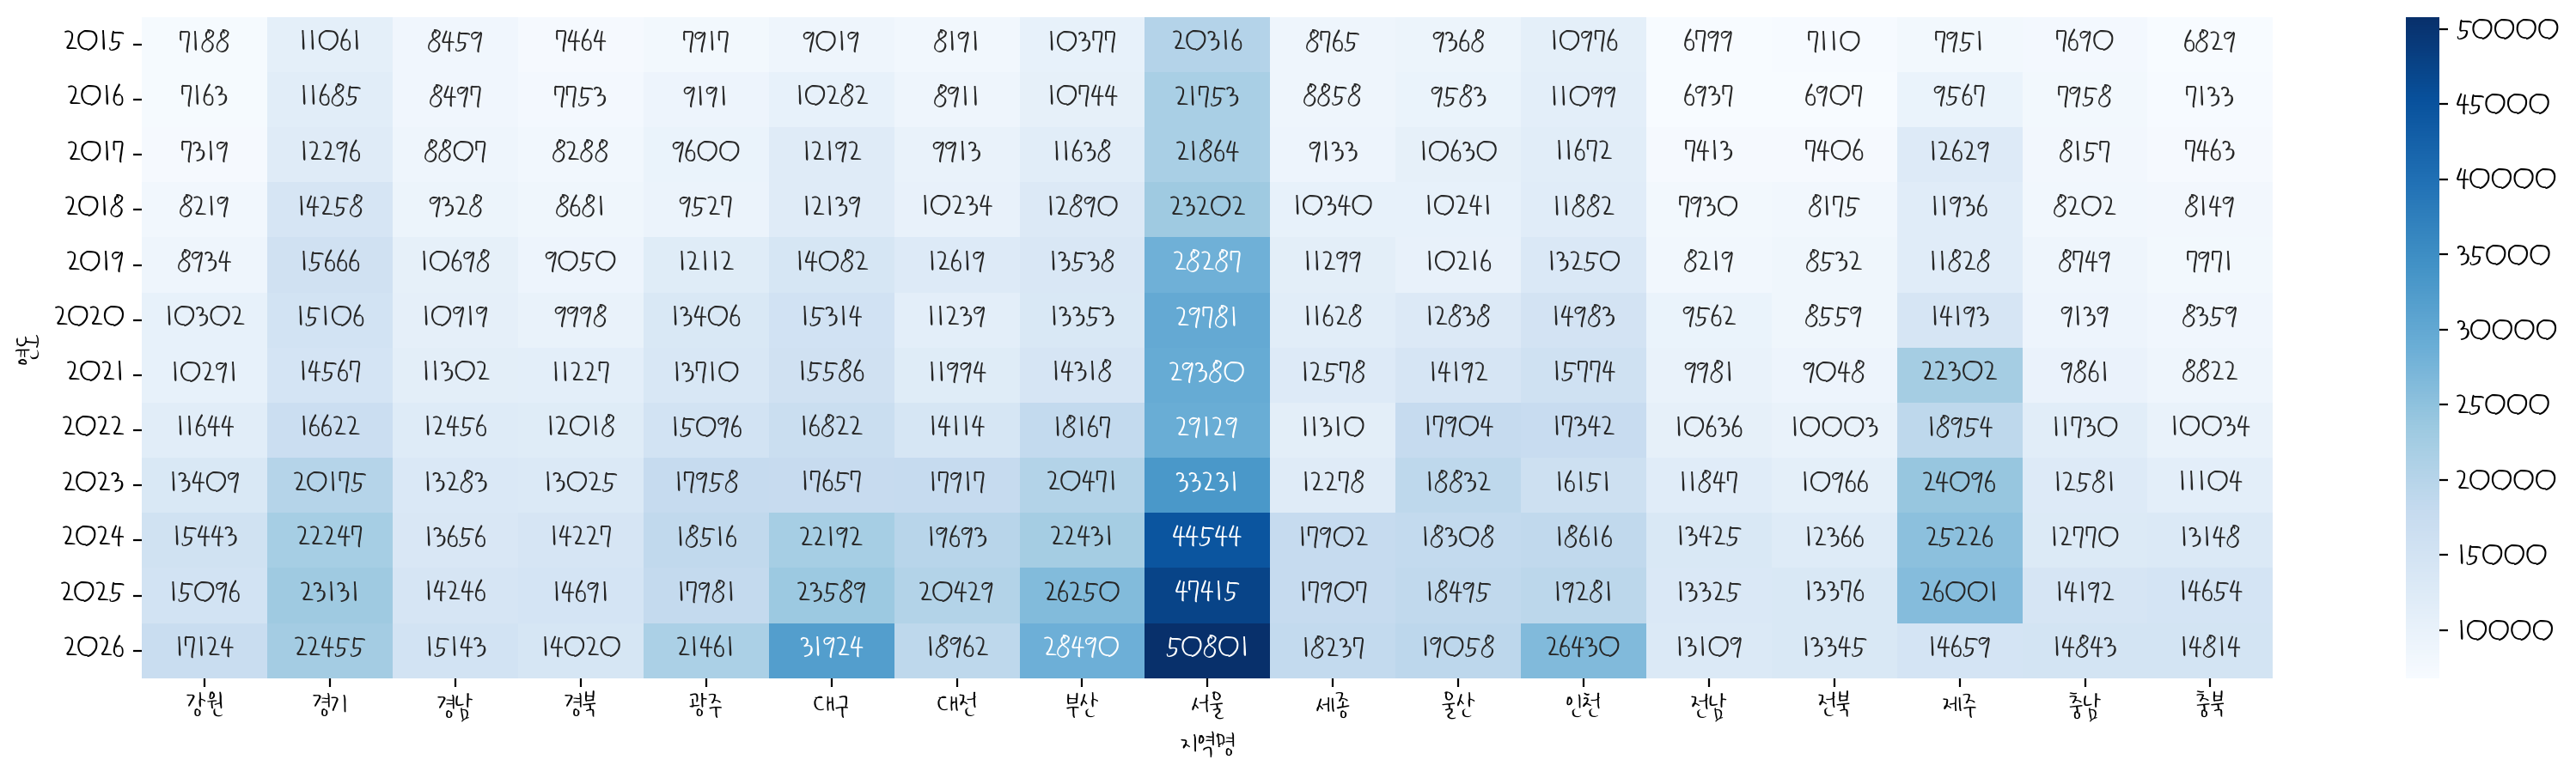

In [45]:
plt.figure(figsize=(20,5))
sns.heatmap(r, annot=True, fmt='.0f', cmap='Blues', annot_kws={'fontsize':12})
plt.show()

- color map 참조 : https://matplotlib.org/stable/users/explain/colors/colormaps.html

# 8. matplotlib으로 시각화(위의 도표)
https://www.research.autodesk.com/publications/same-stats-different-graphs/
## (1) 지역별 결측치를 제외한 데이터수(line, bar)

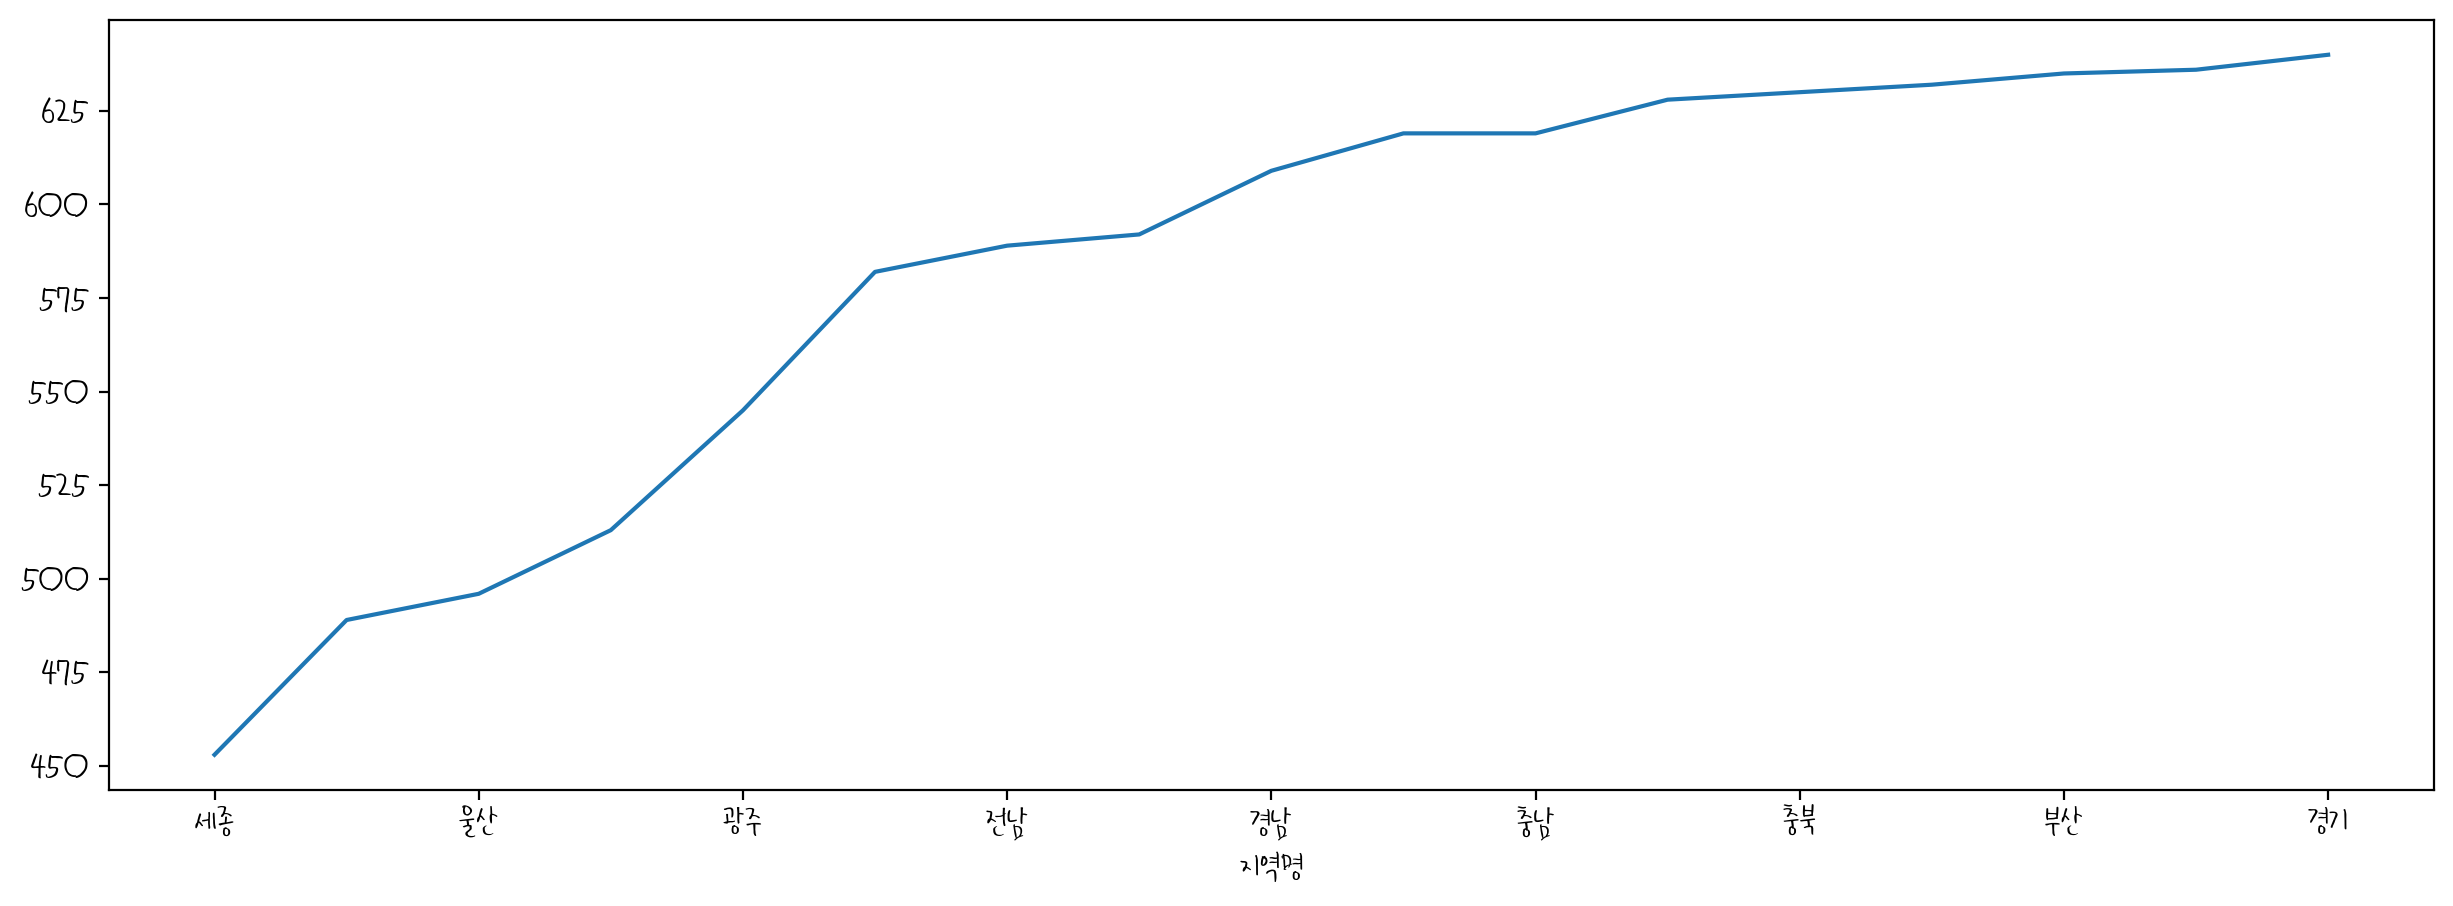

In [54]:
plt.rcParams['figure.figsize'] = [15,5]
df_last.groupby('지역명')['평당 분양가격'].count().sort_values().plot(kind='line')
plt.show()

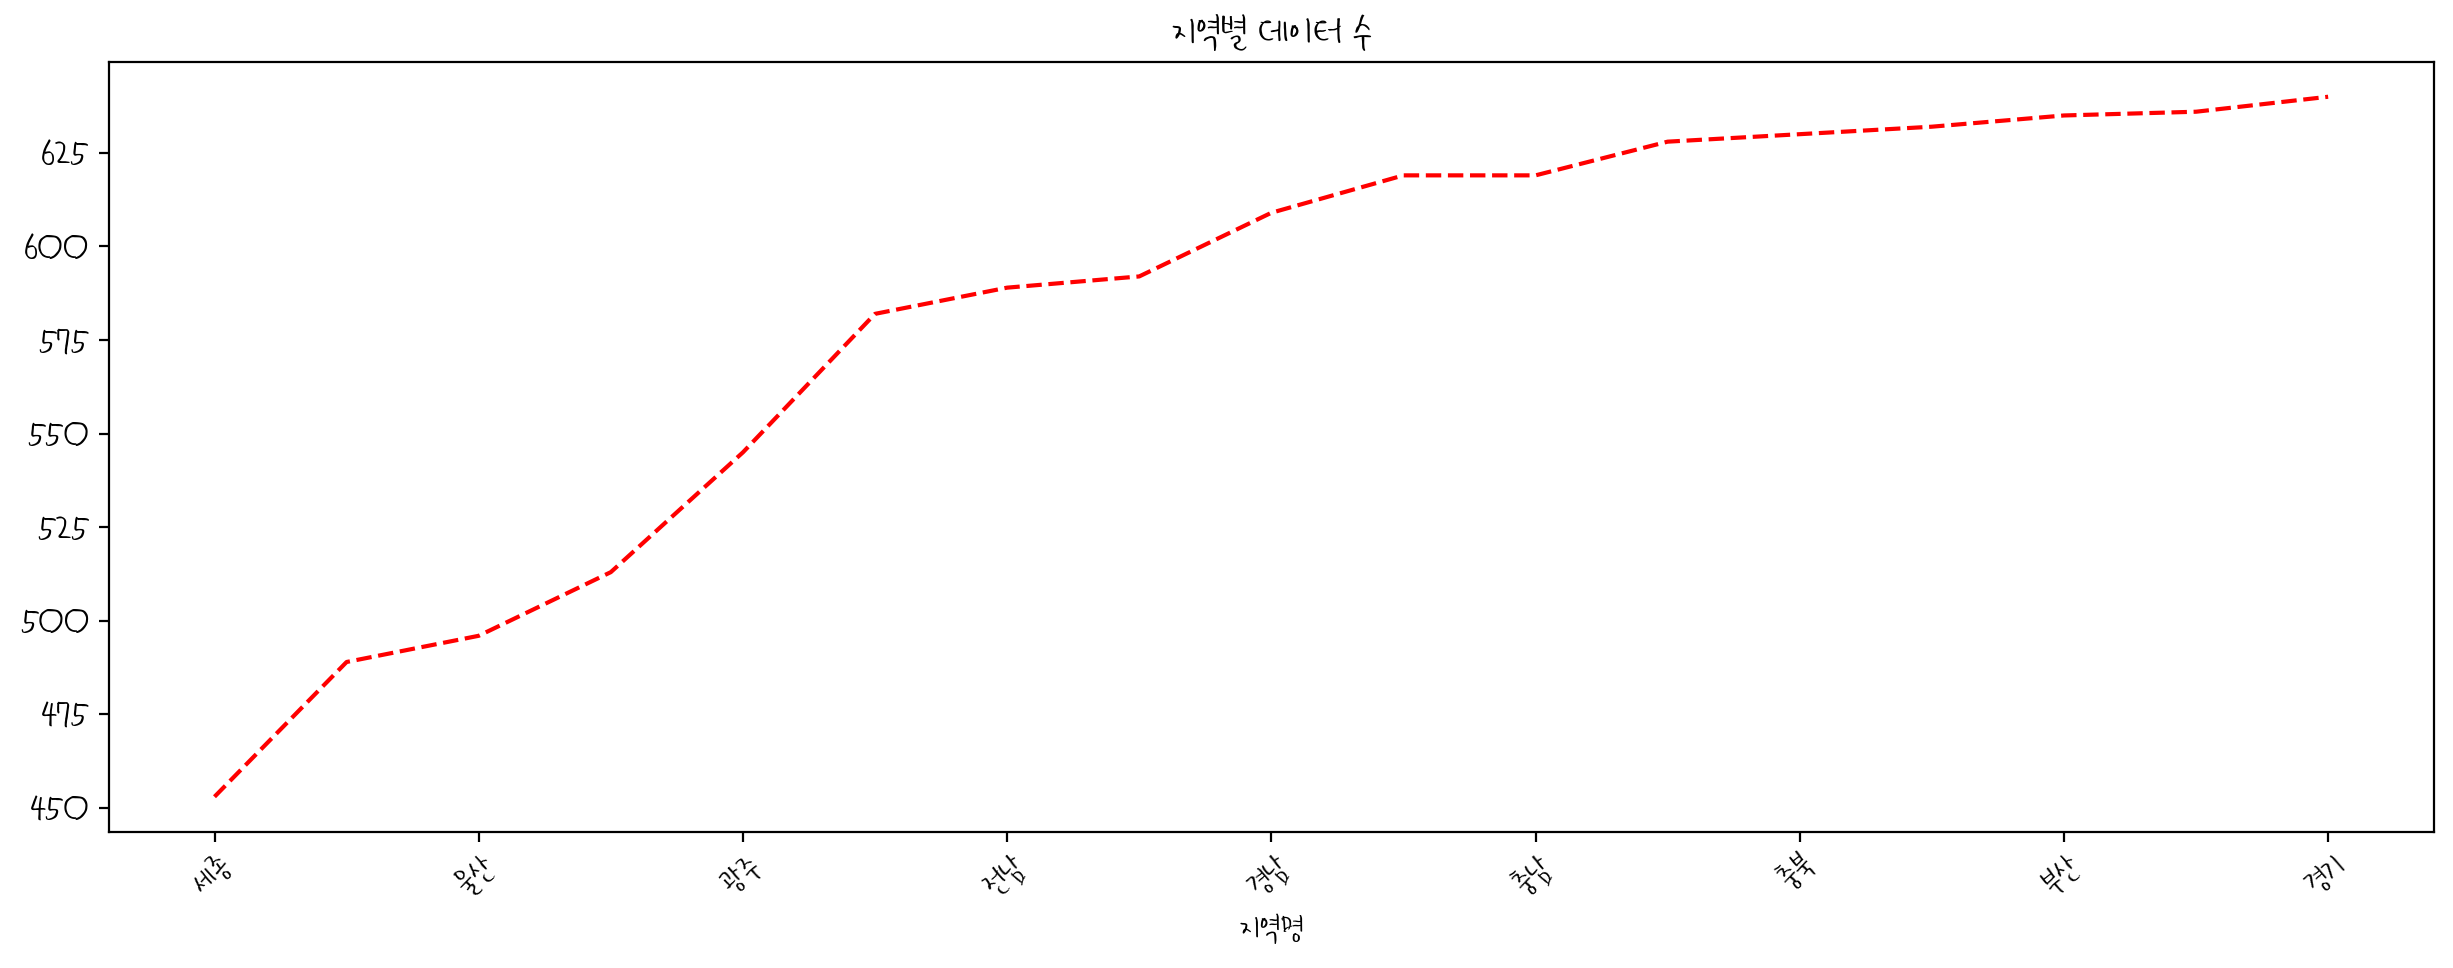

In [60]:
plt.rcParams['figure.figsize'] = [15,5]
df_last.groupby('지역명')['평당 분양가격'].count().sort_values().plot(kind='line', color='r', linestyle='--', rot=40, title='지역별 데이터 수')
plt.show()

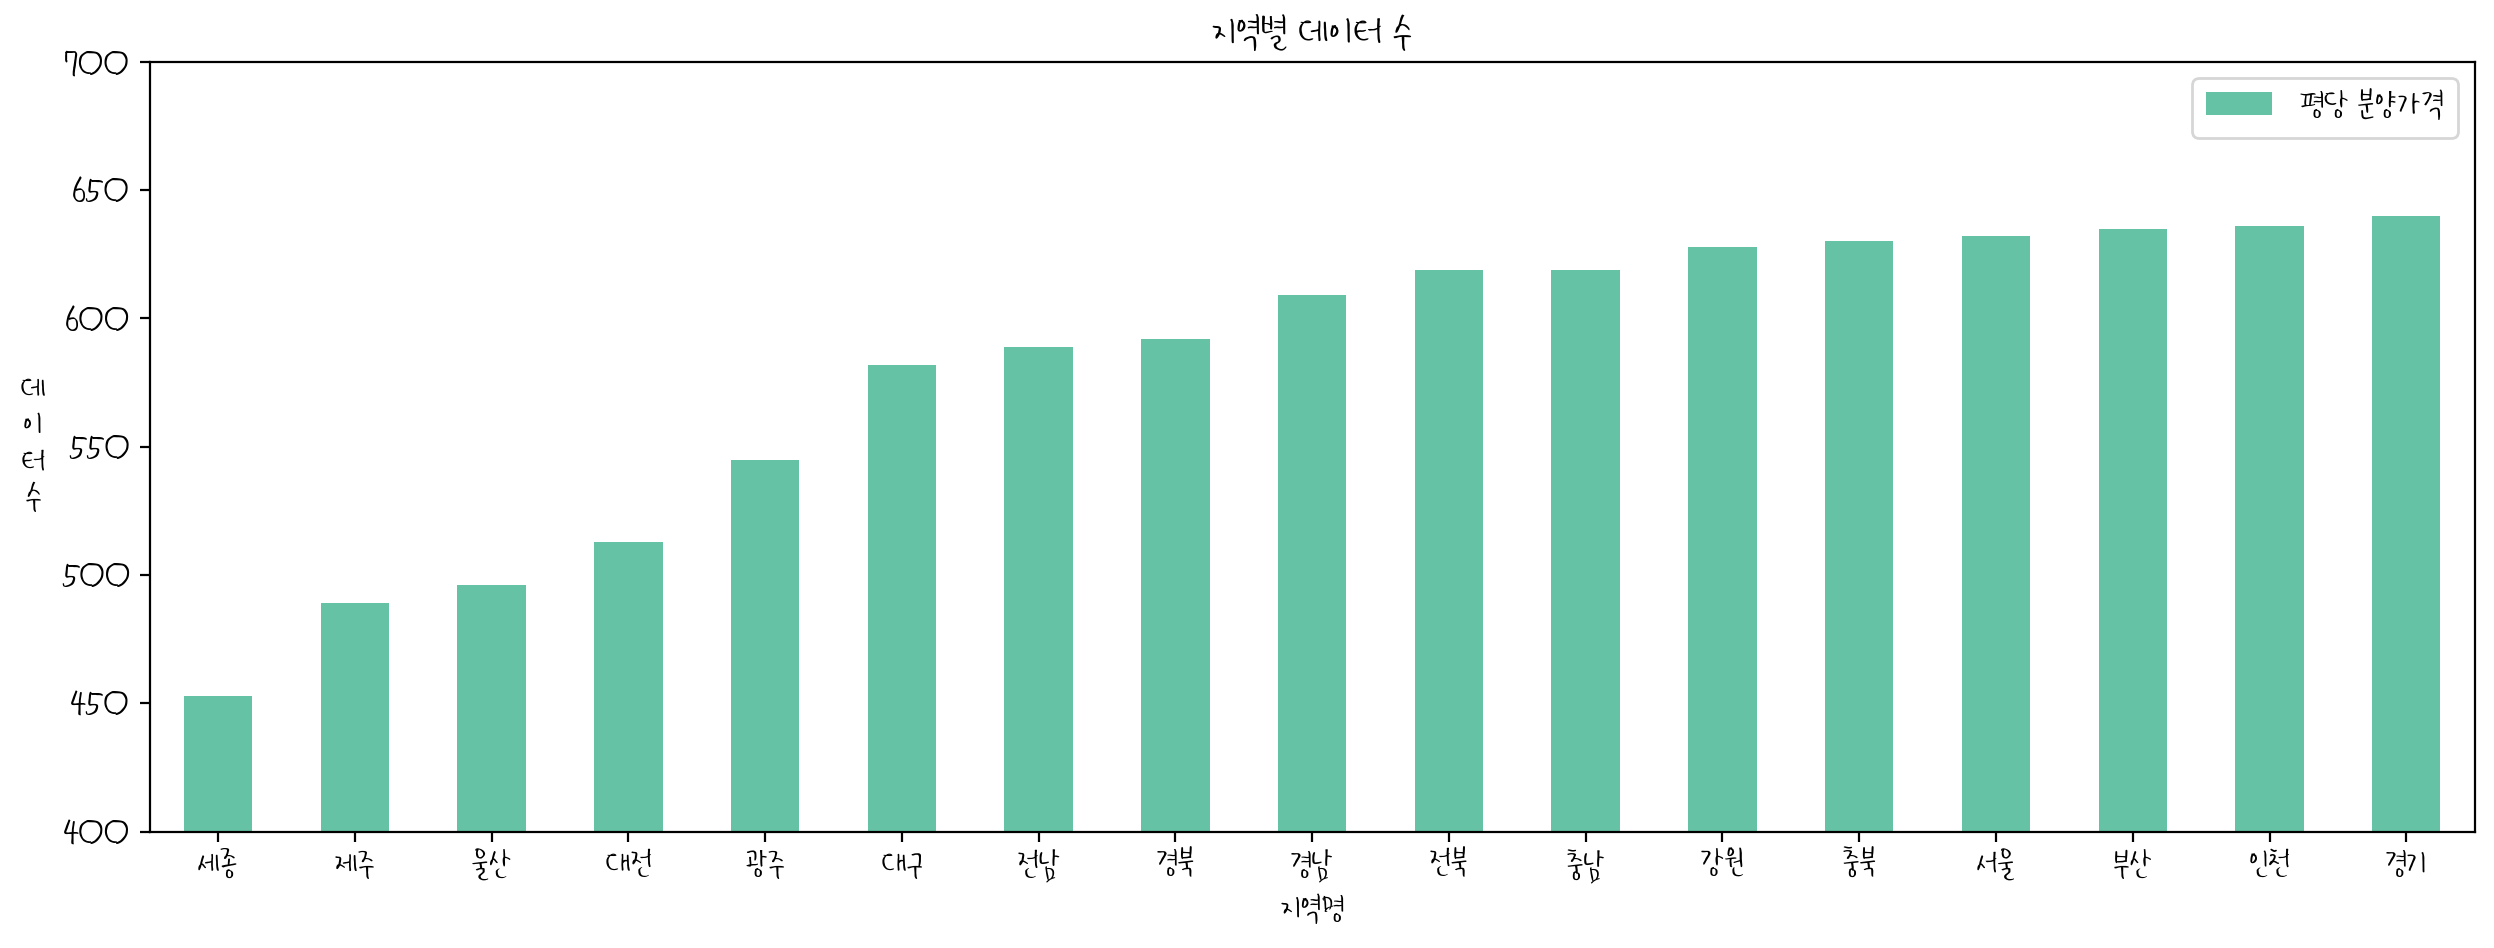

In [81]:
plt.rcParams['figure.figsize'] = [15,5]
ax = df_last.groupby('지역명')[['평당 분양가격']].count().sort_values('평당 분양가격')
ax.plot(kind='bar', colormap='Set2', rot=0, ylim=(400,700))
plt.title('지역별 데이터 수')
plt.ylabel('데\n이\n터\n수', rotation=0, labelpad=10, va='center')
plt.show()

## (2) 지역별 평당분양가격 (line, bar)

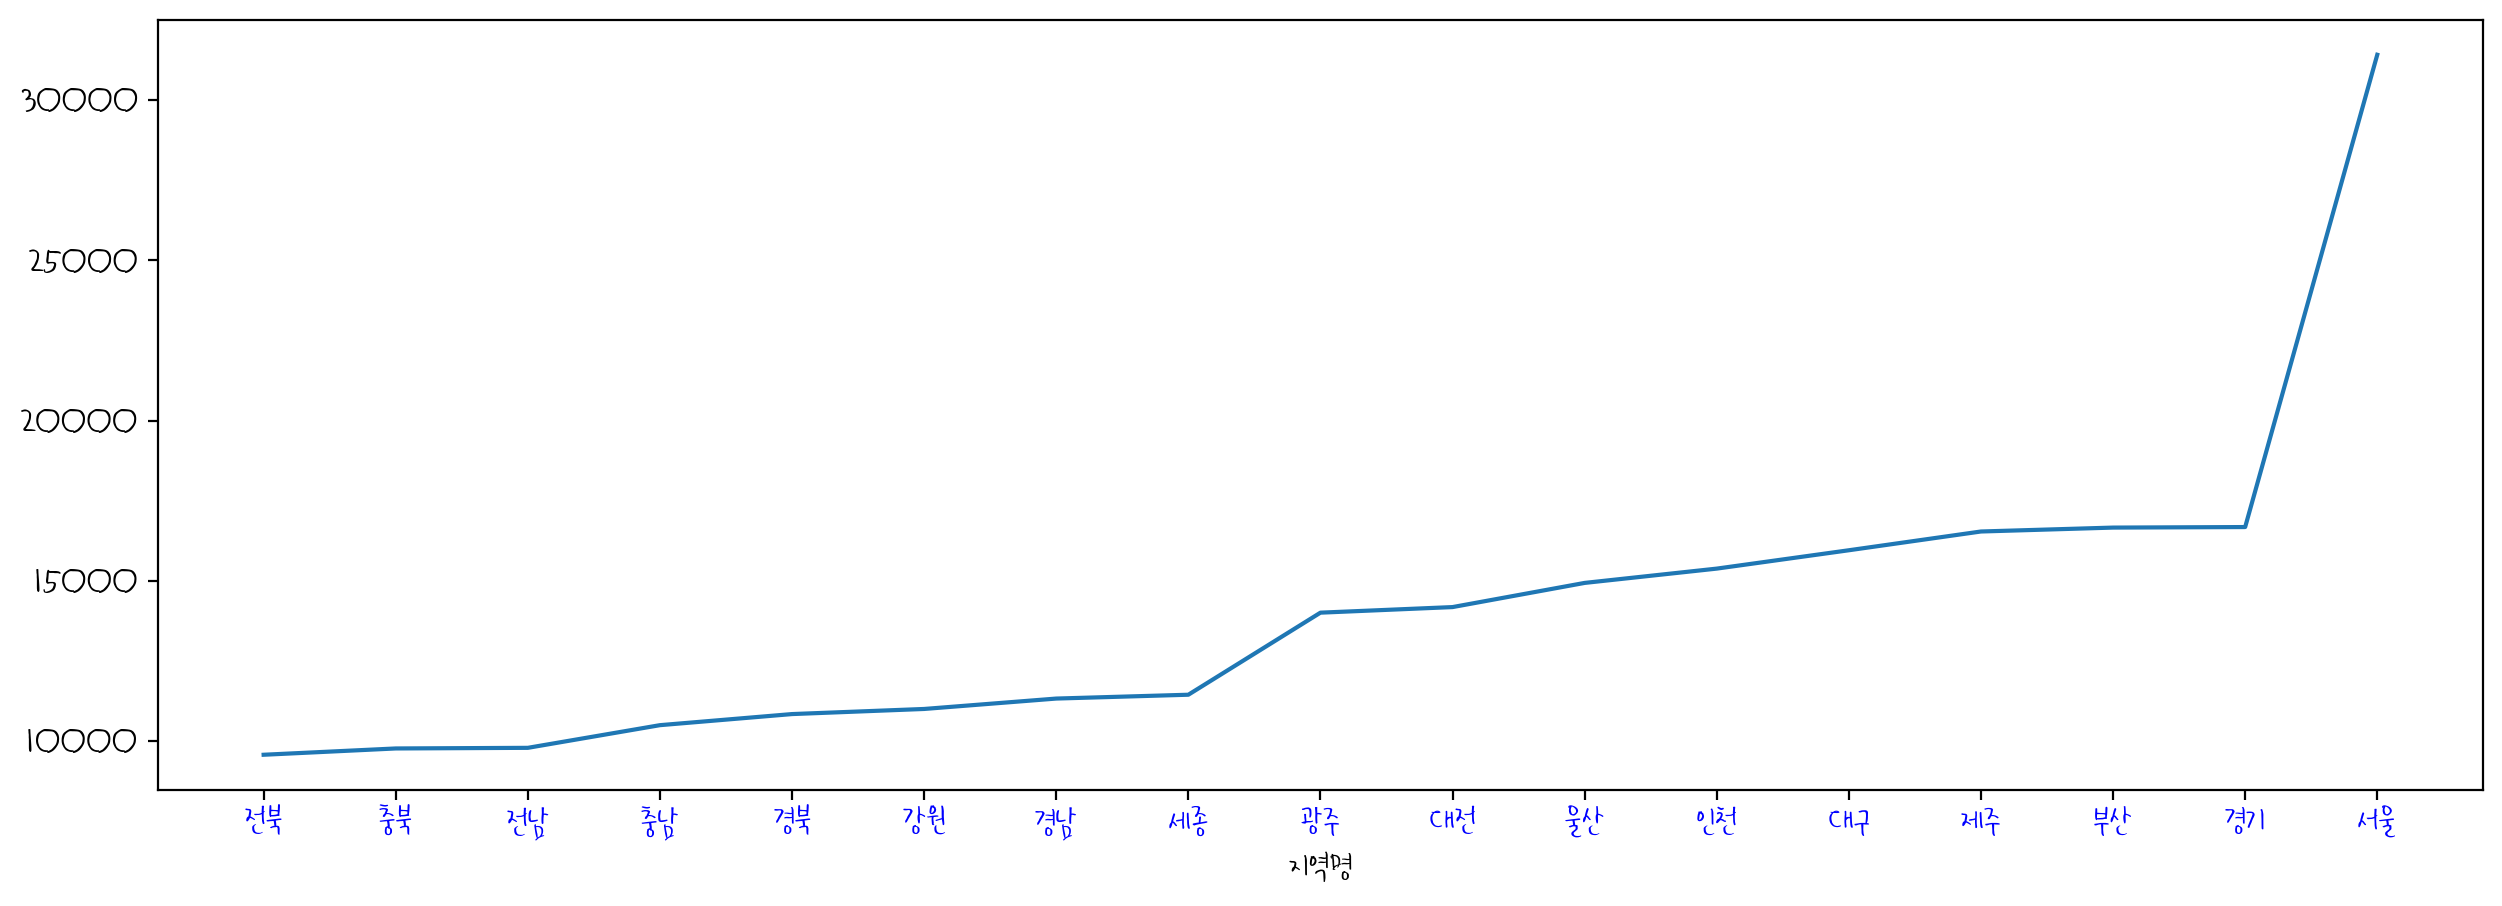

In [86]:
r = df_last.groupby('지역명')['평당 분양가격'].mean().sort_values()
ax = r.plot(kind='line')
plt.xticks(range(len(r)))
ax.set_xticklabels(r.index, color='b')
plt.show()

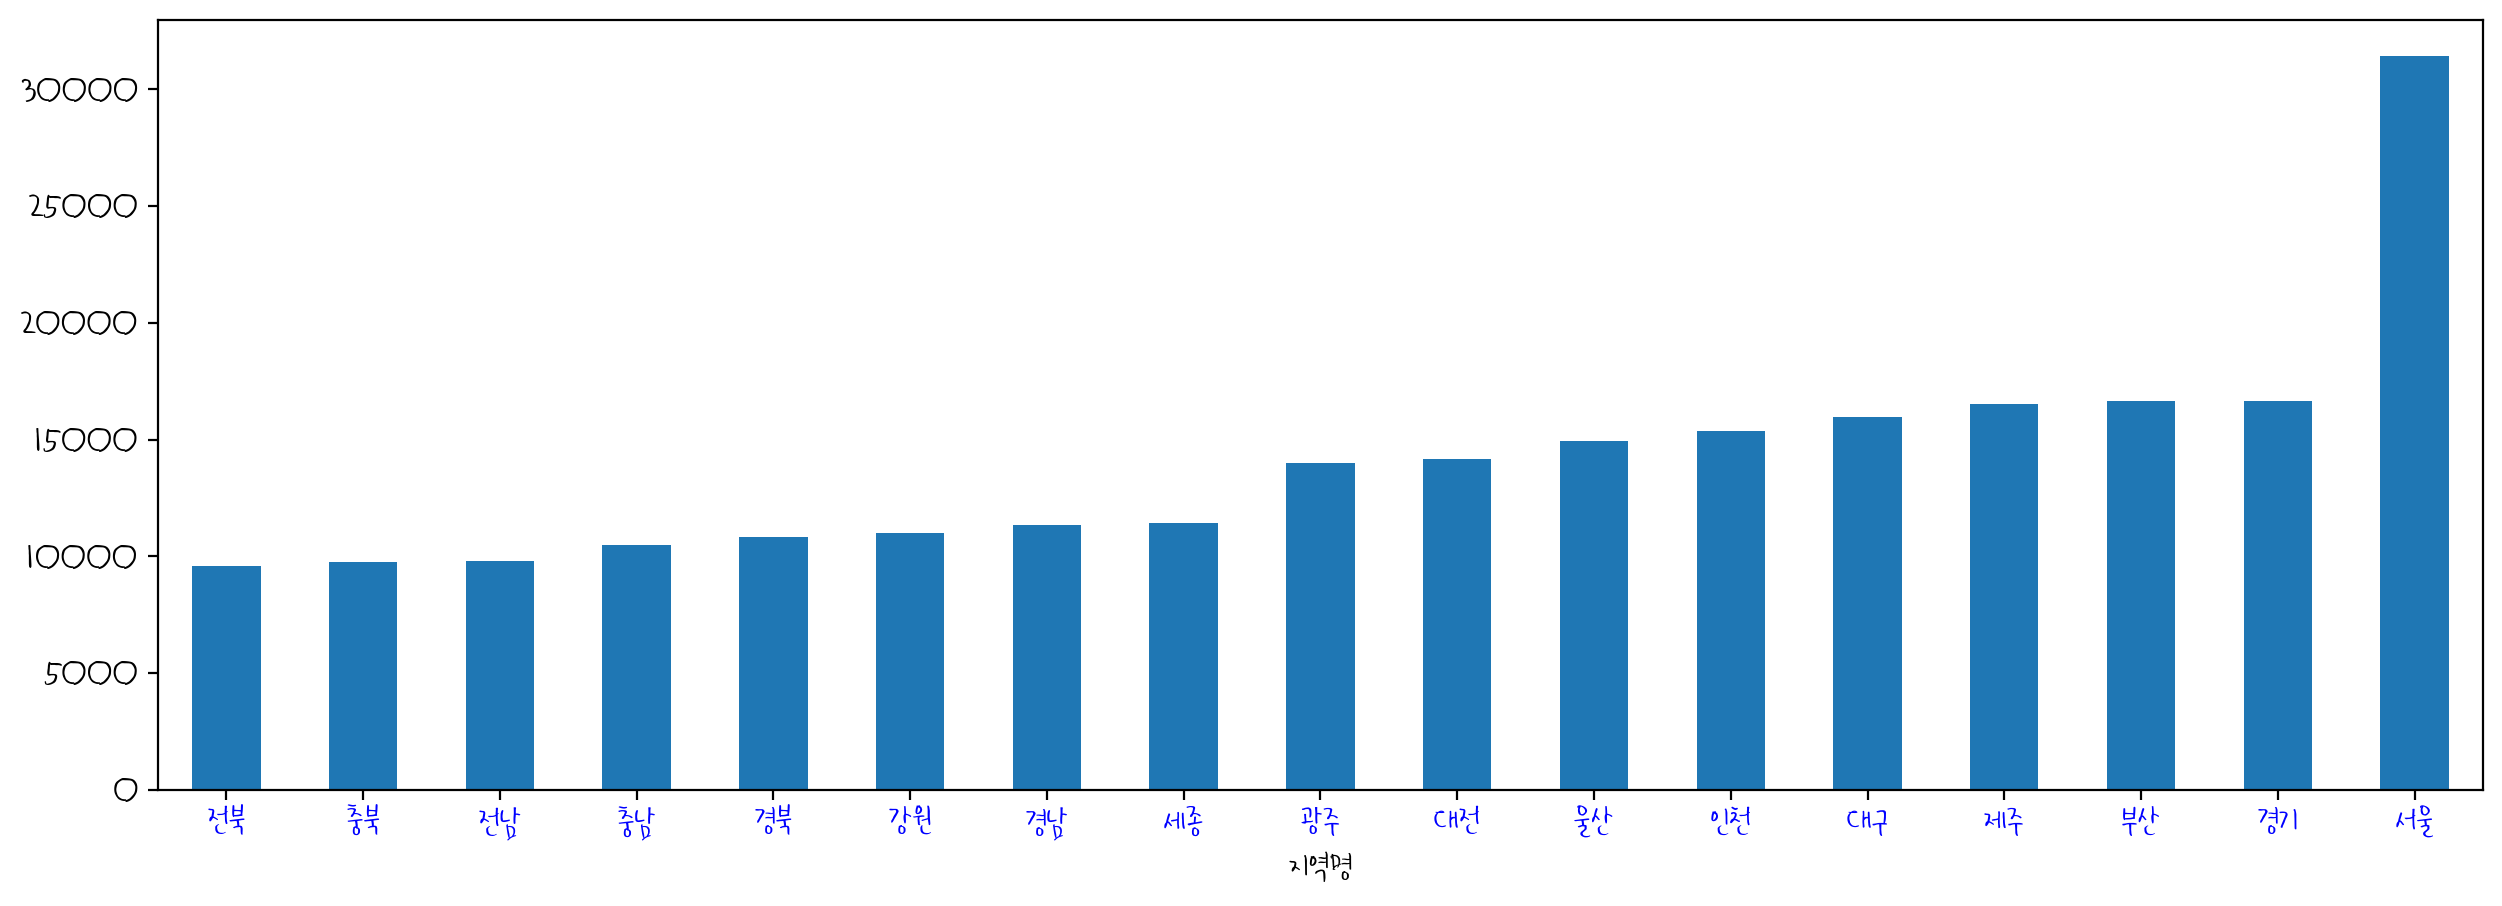

In [88]:
r = df_last.groupby('지역명')['평당 분양가격'].mean().sort_values()
ax = r.plot(kind='bar', rot=0)
plt.xticks(range(len(r)))
ax.set_xticklabels(r.index, color='b')
plt.show()

## (3) 전용면적별 평당분양가격(barplot)

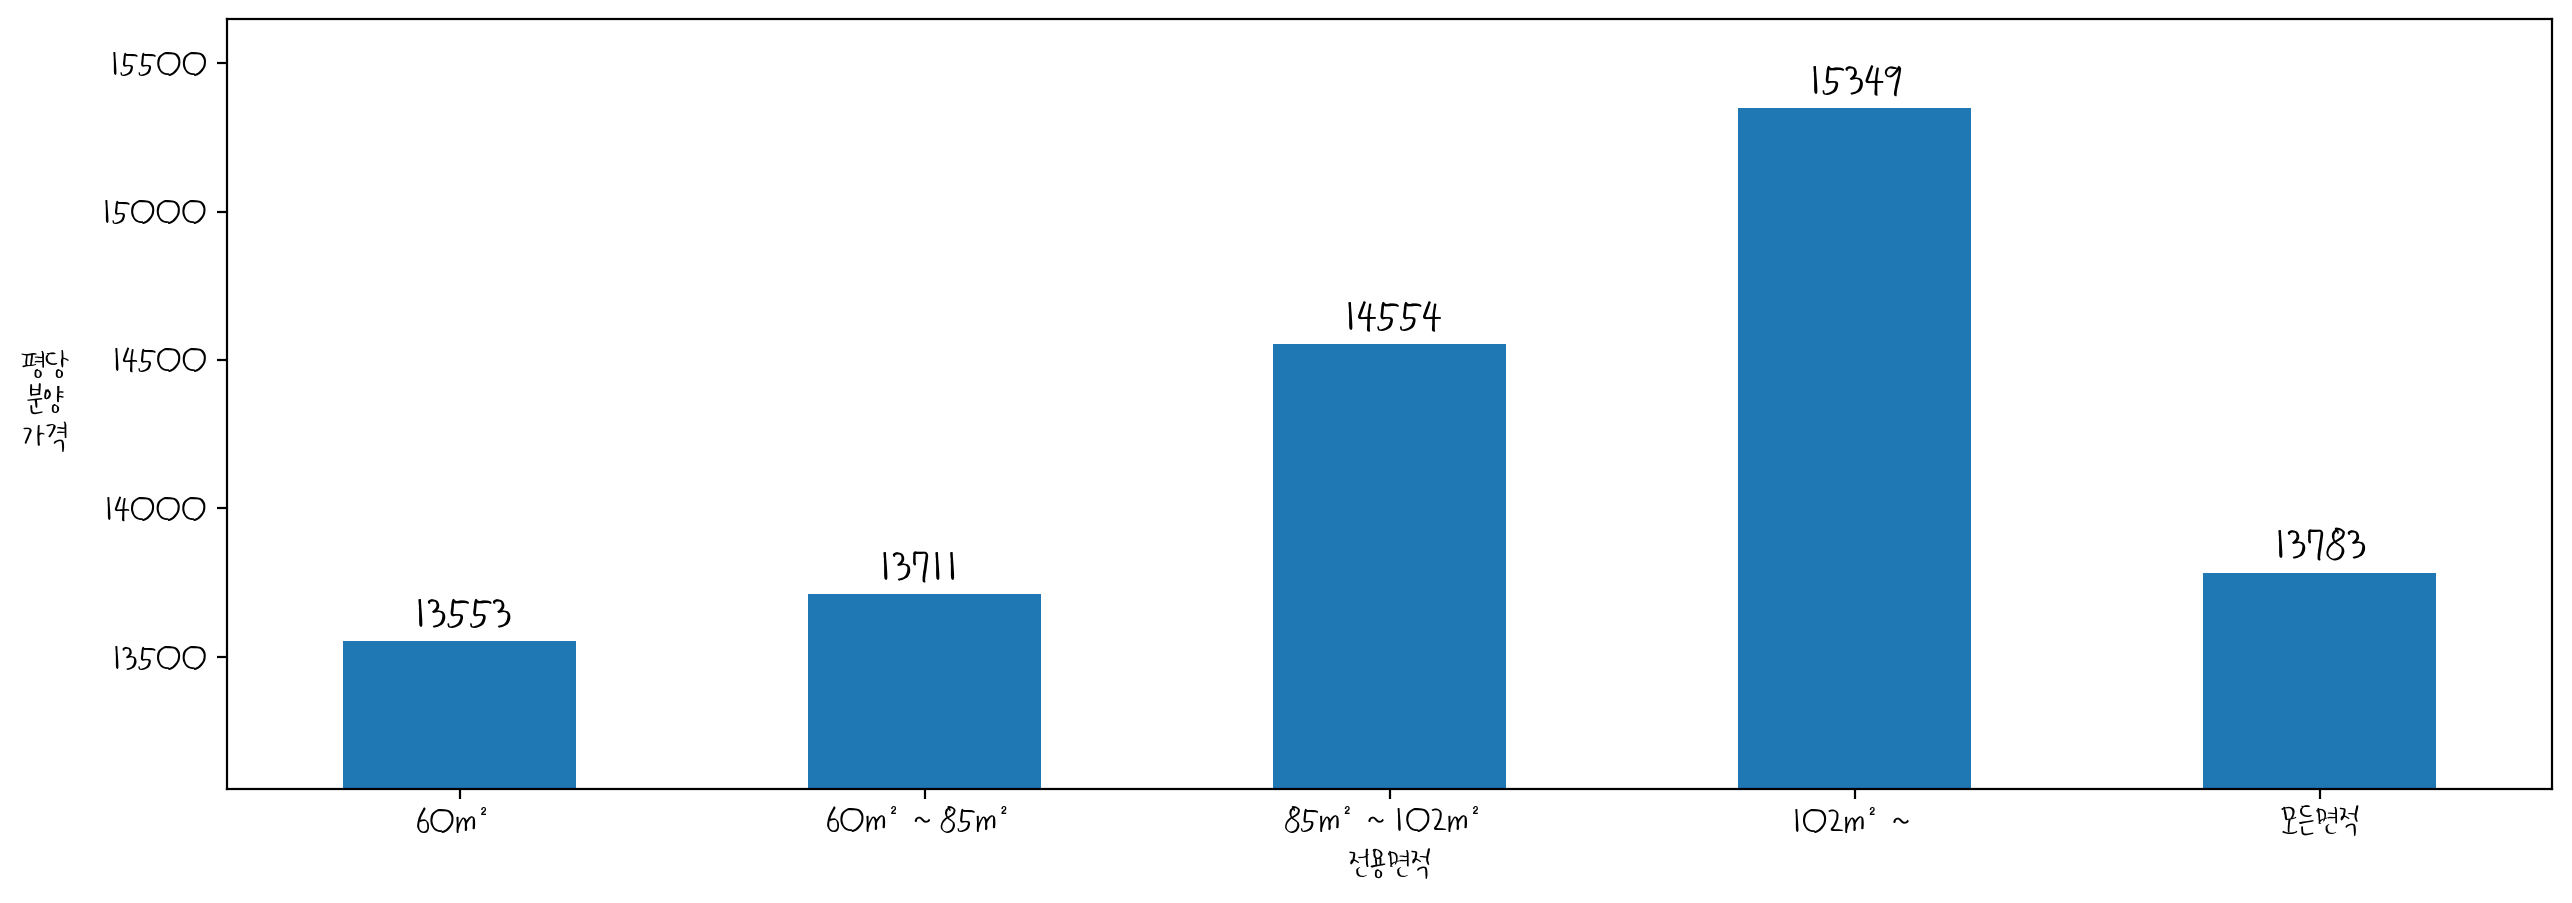

In [117]:
order=['60m²','60m²~ 85m²','85m²~ 102m²','102m²~ ','모든면적']
r = df_last.groupby('전용면적')['평당 분양가격'].mean().reindex(order)
ax = r.plot(kind='bar', rot=0, ylim=[r.min()-500, r.max()+300])
plt.xticks(range(len(r)))
plt.ylabel('평당\n분양\n가격', rotation=0, labelpad=20, va='center')
ax.set_xticklabels(r.index)
for i, val in enumerate(r):
    plt.text(i-0.1, val+50, round(val), fontsize=15) # 수치를 통한 위치 변경
plt.show()

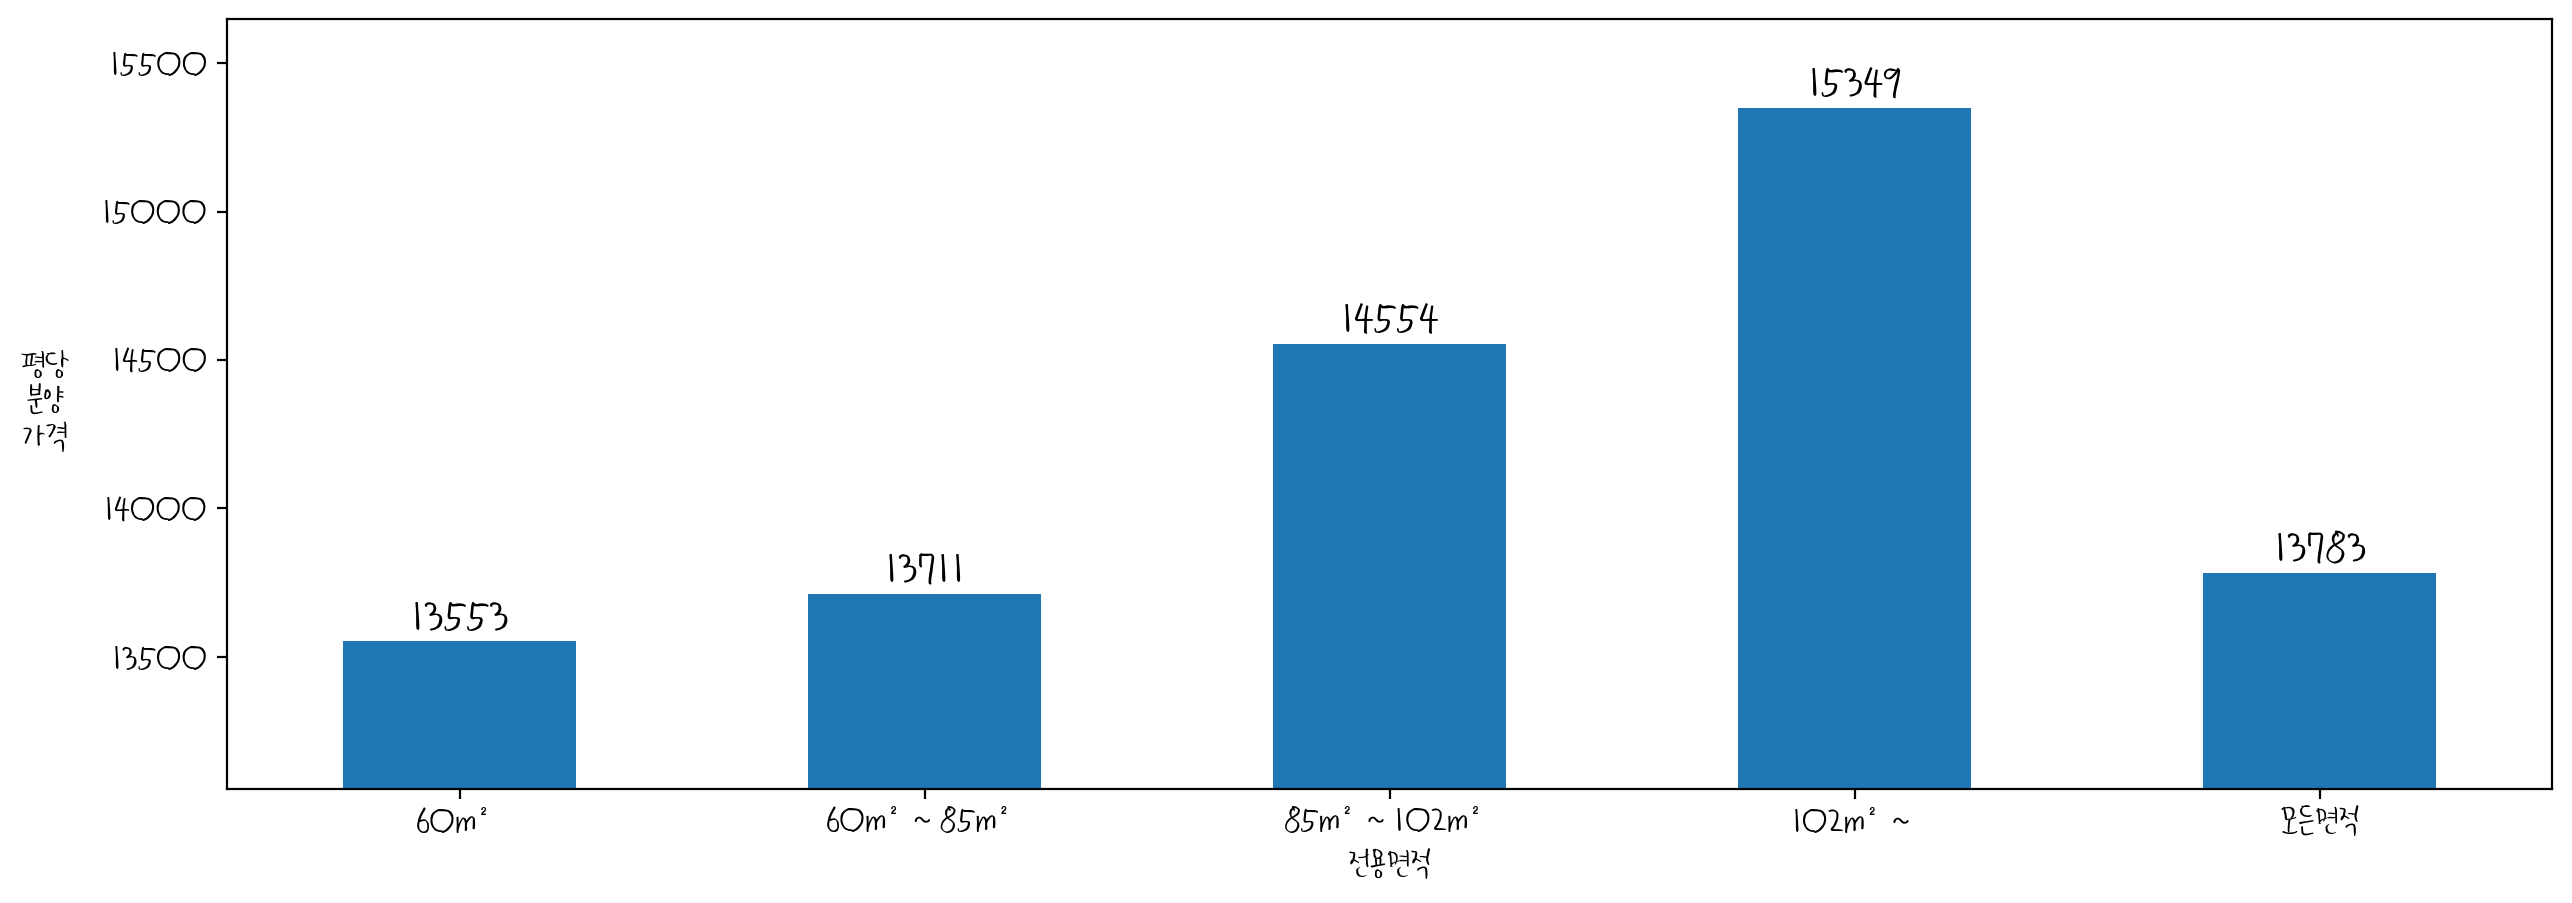

In [121]:
order=['60m²','60m²~ 85m²','85m²~ 102m²','102m²~ ','모든면적']
r = df_last.groupby('전용면적')['평당 분양가격'].mean().reindex(order)
ax = r.plot(kind='bar', rot=0, ylim=[r.min()-500, r.max()+300])
plt.xticks(range(len(r)))
plt.ylabel('평당\n분양\n가격', rotation=0, labelpad=20, va='center')
ax.set_xticklabels(r.index)
for i, val in enumerate(r):
    plt.text(i, val, round(val), fontsize=15, va='bottom', ha='center') # va/ha를 사용한 위치 변경
plt.show()

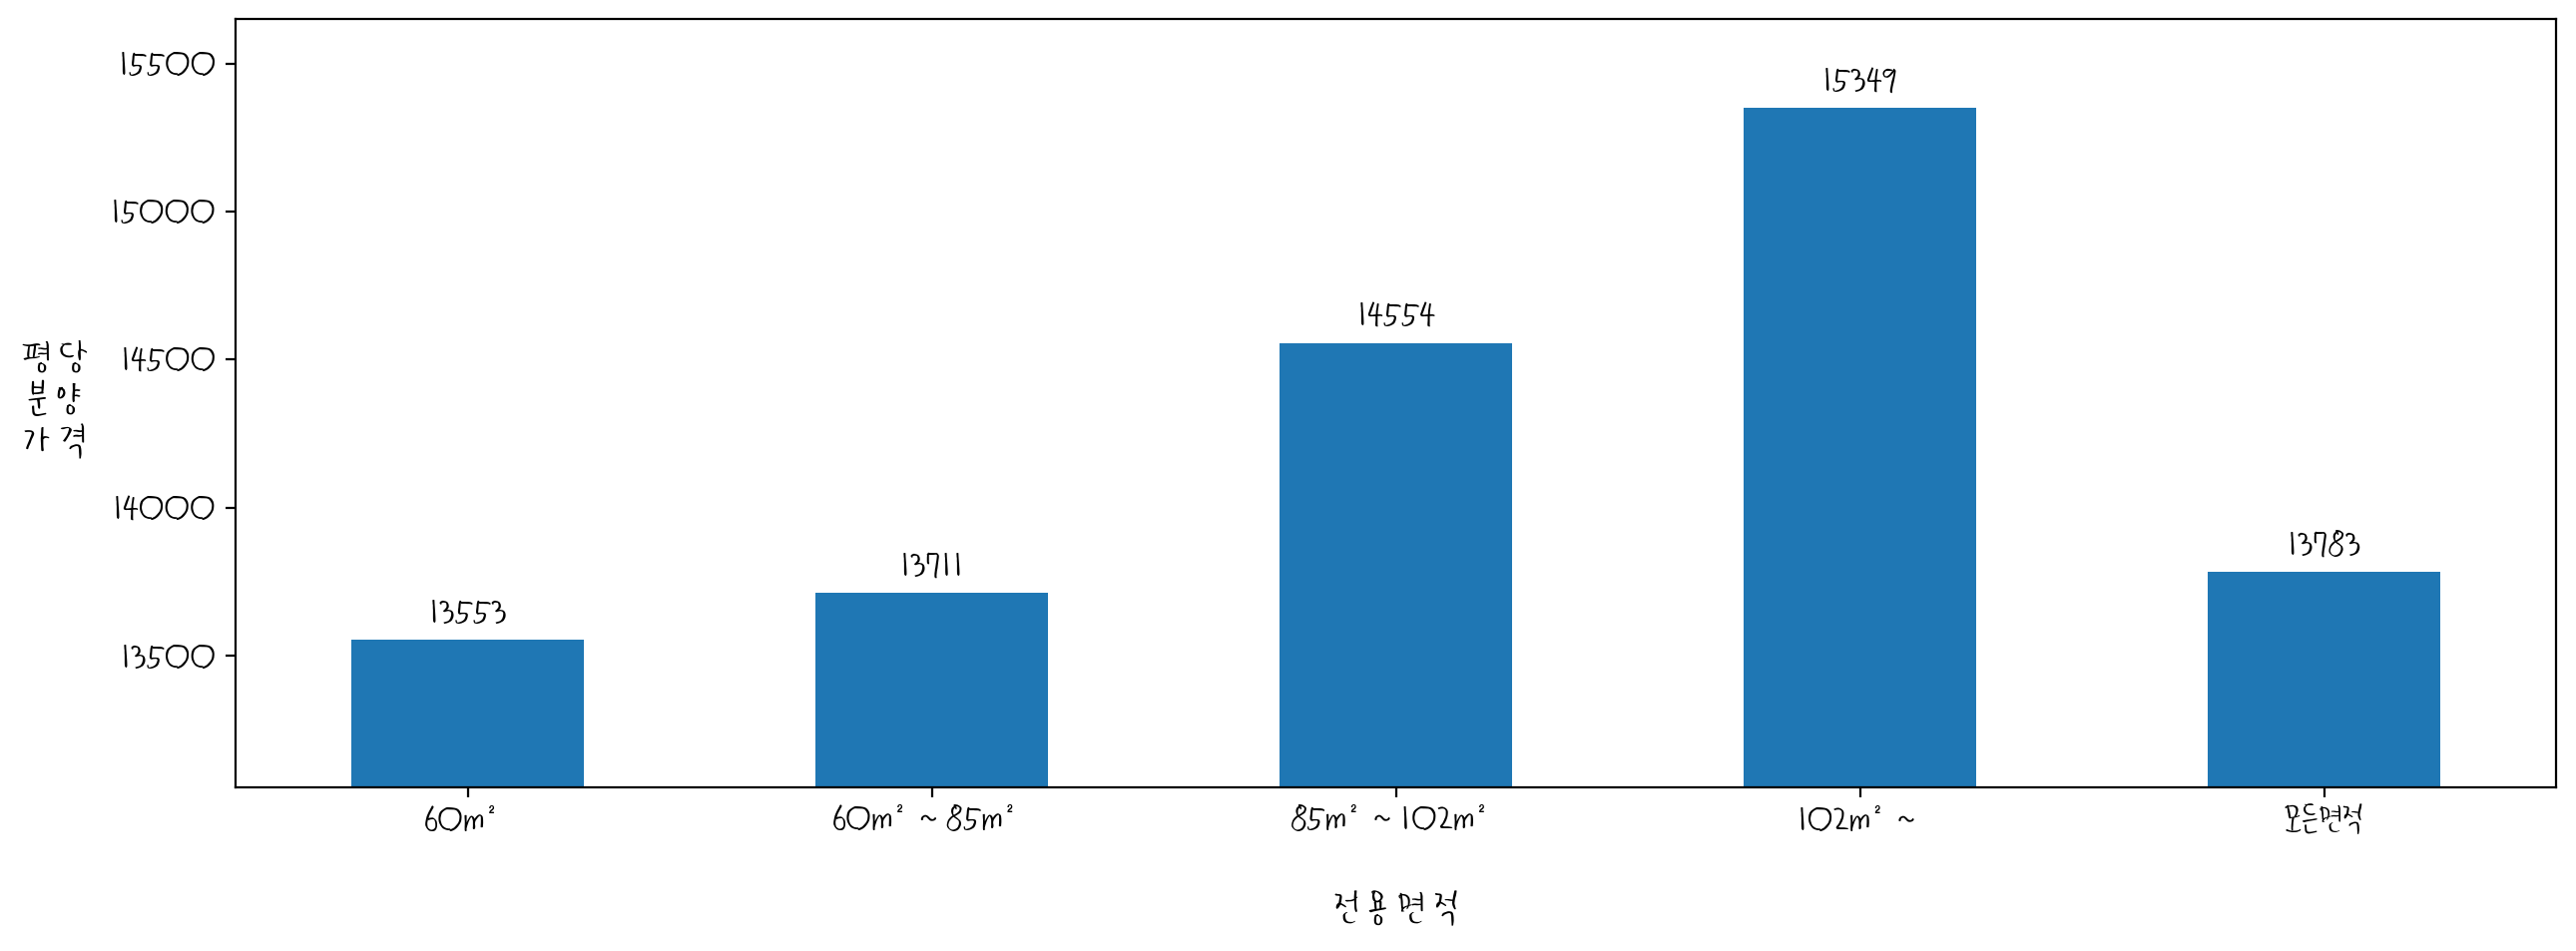

In [127]:
order=['60m²','60m²~ 85m²','85m²~ 102m²','102m²~ ','모든면적']
r = df_last.groupby('전용면적')['평당 분양가격'].mean().reindex(order)
ax = r.plot(kind='bar', rot=0, ylim=[r.min()-500, r.max()+300])
plt.xticks(range(len(r)))
plt.ylabel('평 당\n분 양\n가 격', rotation=0, labelpad=20, va='center', fontsize=14)
plt.xlabel('전 용 면 적', rotation=0, labelpad=20, ha='center', fontsize=14)
ax.set_xticklabels(r.index)
ax.bar_label(ax.containers[0], fmt='%.0f', padding=3) # bar_label을 이용한 값 표기
plt.show()

## (4) 연도별 평균 평당분양가격(line)

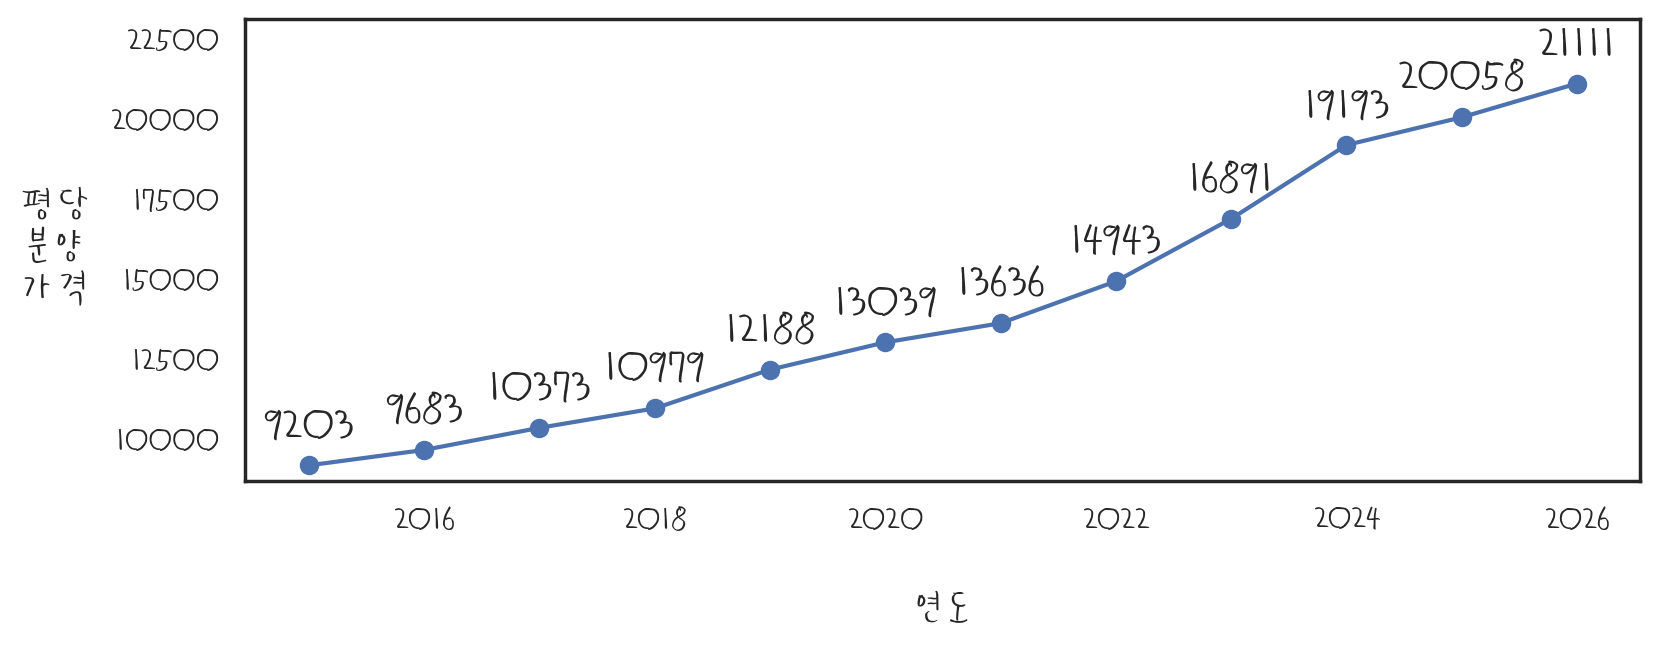

In [187]:
r = df_last.groupby('연도')['평당 분양가격'].mean()
ax = r.plot(kind='line',marker='o', ylim=[r.min()-500,r.max()+2000])

plt.ylabel('평 당\n분 양\n가 격', rotation=0, labelpad=20, va='center', fontsize=14)
plt.xlabel('연 도', rotation=0, labelpad=20, ha='center', fontsize=14)

for year, val in r.items():
    plt.text(year, val+500, round(val), fontsize=15, va='bottom', ha='center')

plt.show()

범례:https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot

# 9. seaborn으로 시각화
- 위에서 시각화한 내용을 seaborn으로 시각화

In [155]:
sns.set(style='white', rc={'figure.figsize':(9,3)})
plt.rc('font', family='Malgun Gothic') # 윈도우즈
plt.rc('axes', unicode_minus=False) # 축의 - 깨짐 방지

## (1) 지역별 평당분양가격

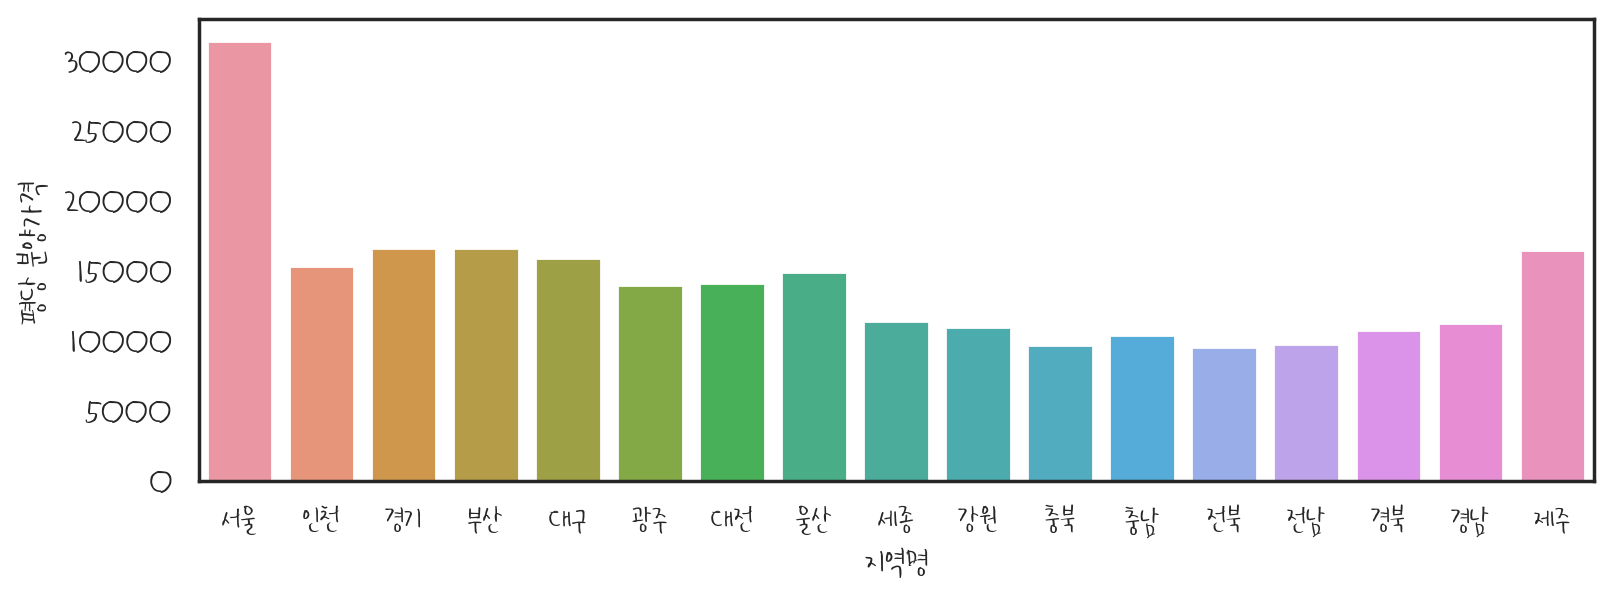

In [160]:
sns.barplot(data=df_last, x='지역명', y='평당 분양가격', errorbar=None, )
plt.show()

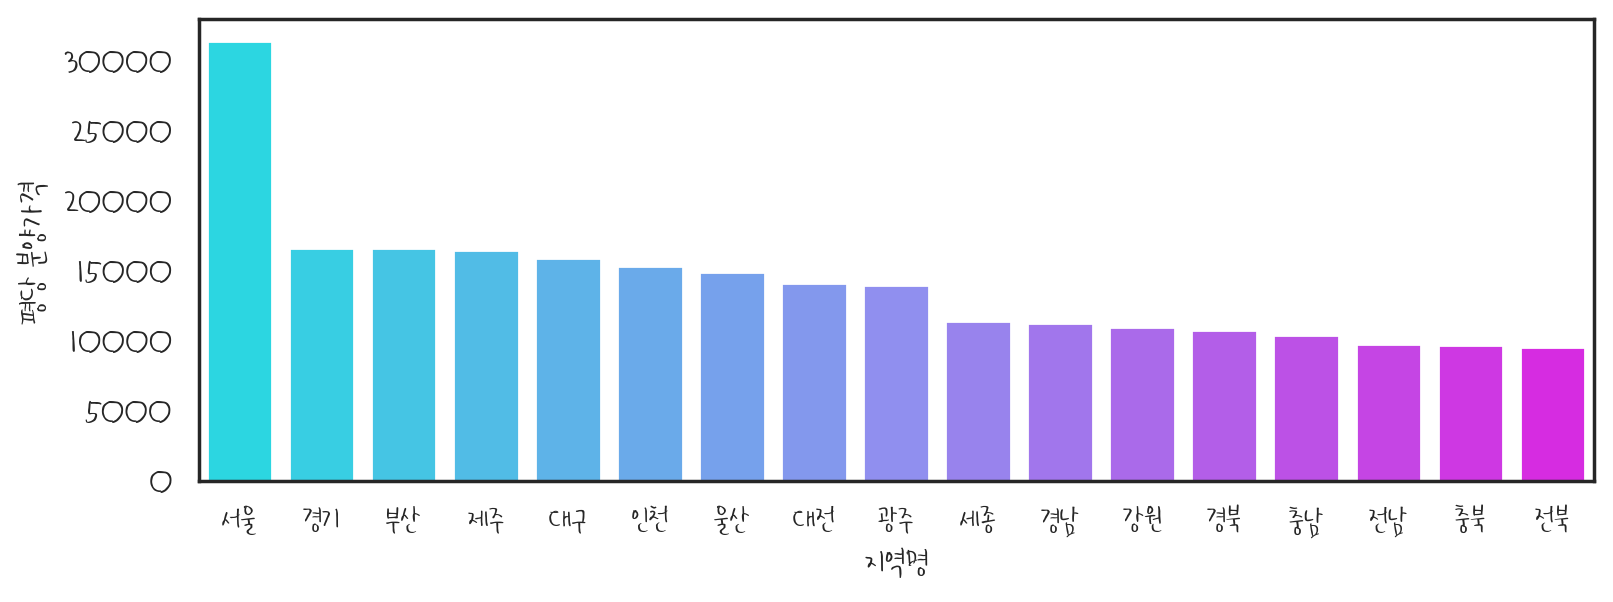

In [171]:
r = df_last.groupby('지역명')['평당 분양가격'].mean().sort_values(ascending=False)
sns.barplot(data=df_last, x='지역명', y='평당 분양가격', errorbar=None, order=(r.index), palette='cool')
plt.show()

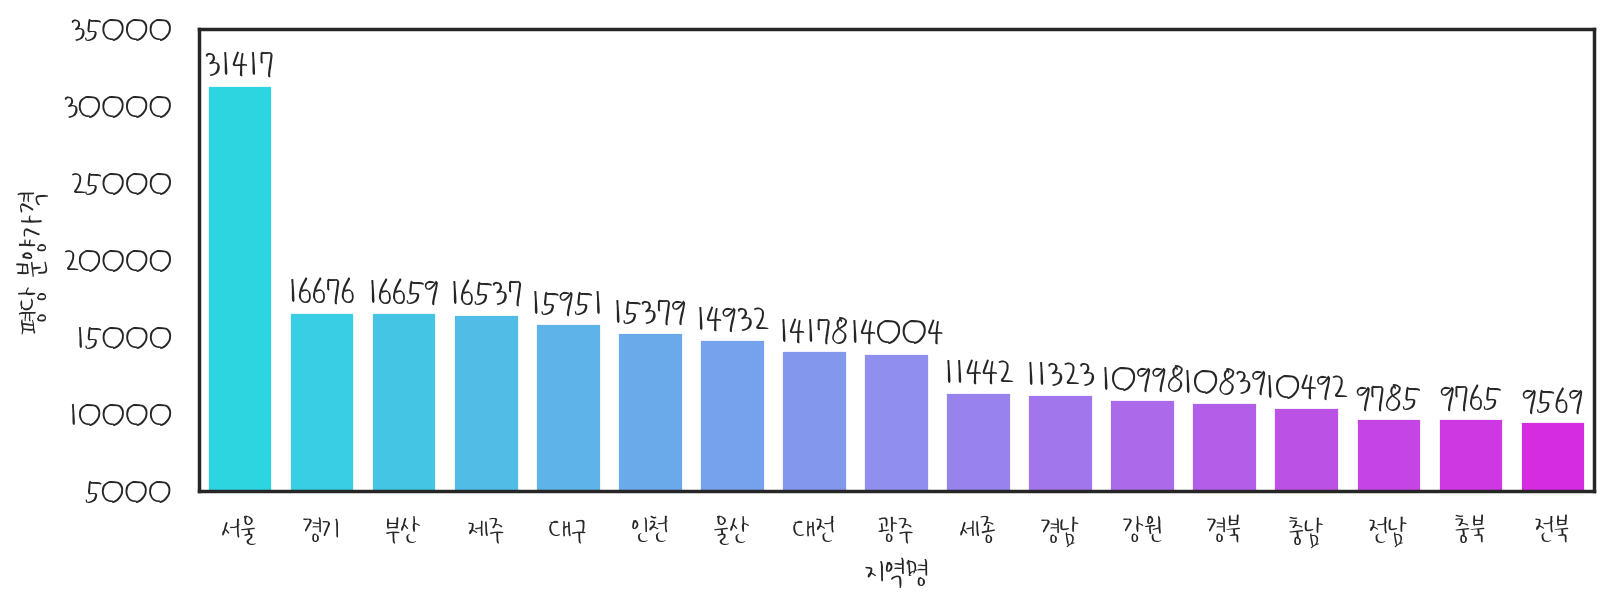

In [189]:
r = df_last.groupby('지역명')['평당 분양가격'].mean().sort_values(ascending=False)
ax = sns.barplot(data=df_last, x='지역명', y='평당 분양가격', errorbar=None, order=(r.index), palette='cool')

for i, val in enumerate(r):
    plt.text(i, val, round(val), va='bottom', ha='center')

ax.set_ylim([5000, 35000])
plt.show()

## (2) 연도별 평당분양가격

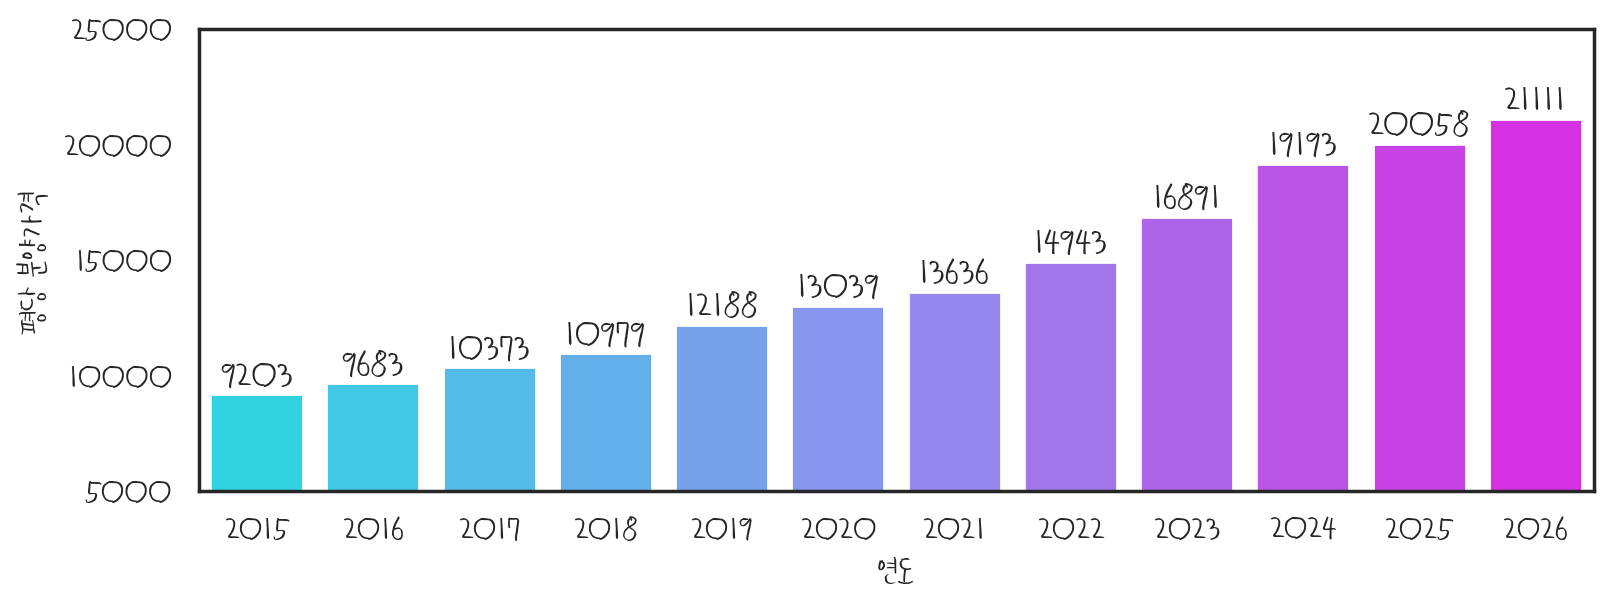

In [196]:
r = df_last.groupby('연도')['평당 분양가격'].mean().sort_values()
ax = sns.barplot(data=df_last, x='연도', y='평당 분양가격', errorbar=None, order=(r.index), palette='cool')

for i, val in enumerate(r):
    plt.text(i, val, round(val), va='bottom', ha='center')

ax.set_ylim([5000, 25000])
plt.show()

## (3) 그 외 lineplot, relplot, boxplot, violinplot, boxexplot, regplot, swarmplot

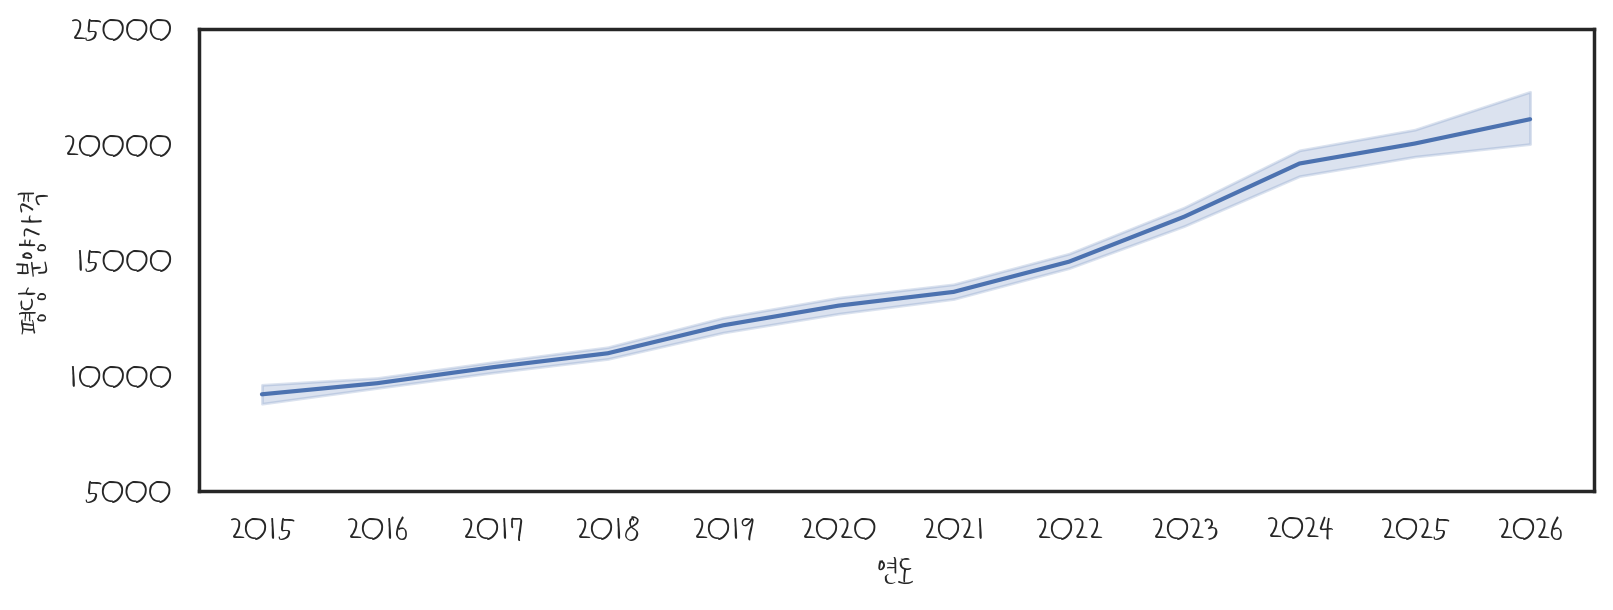

In [201]:
r = df_last.groupby('연도')['평당 분양가격'].mean().sort_values()
ax = sns.lineplot(data=df_last, x='연도', y='평당 분양가격')
plt.xticks(range(2015,2027))
ax.set_ylim([5000, 25000])
plt.show()

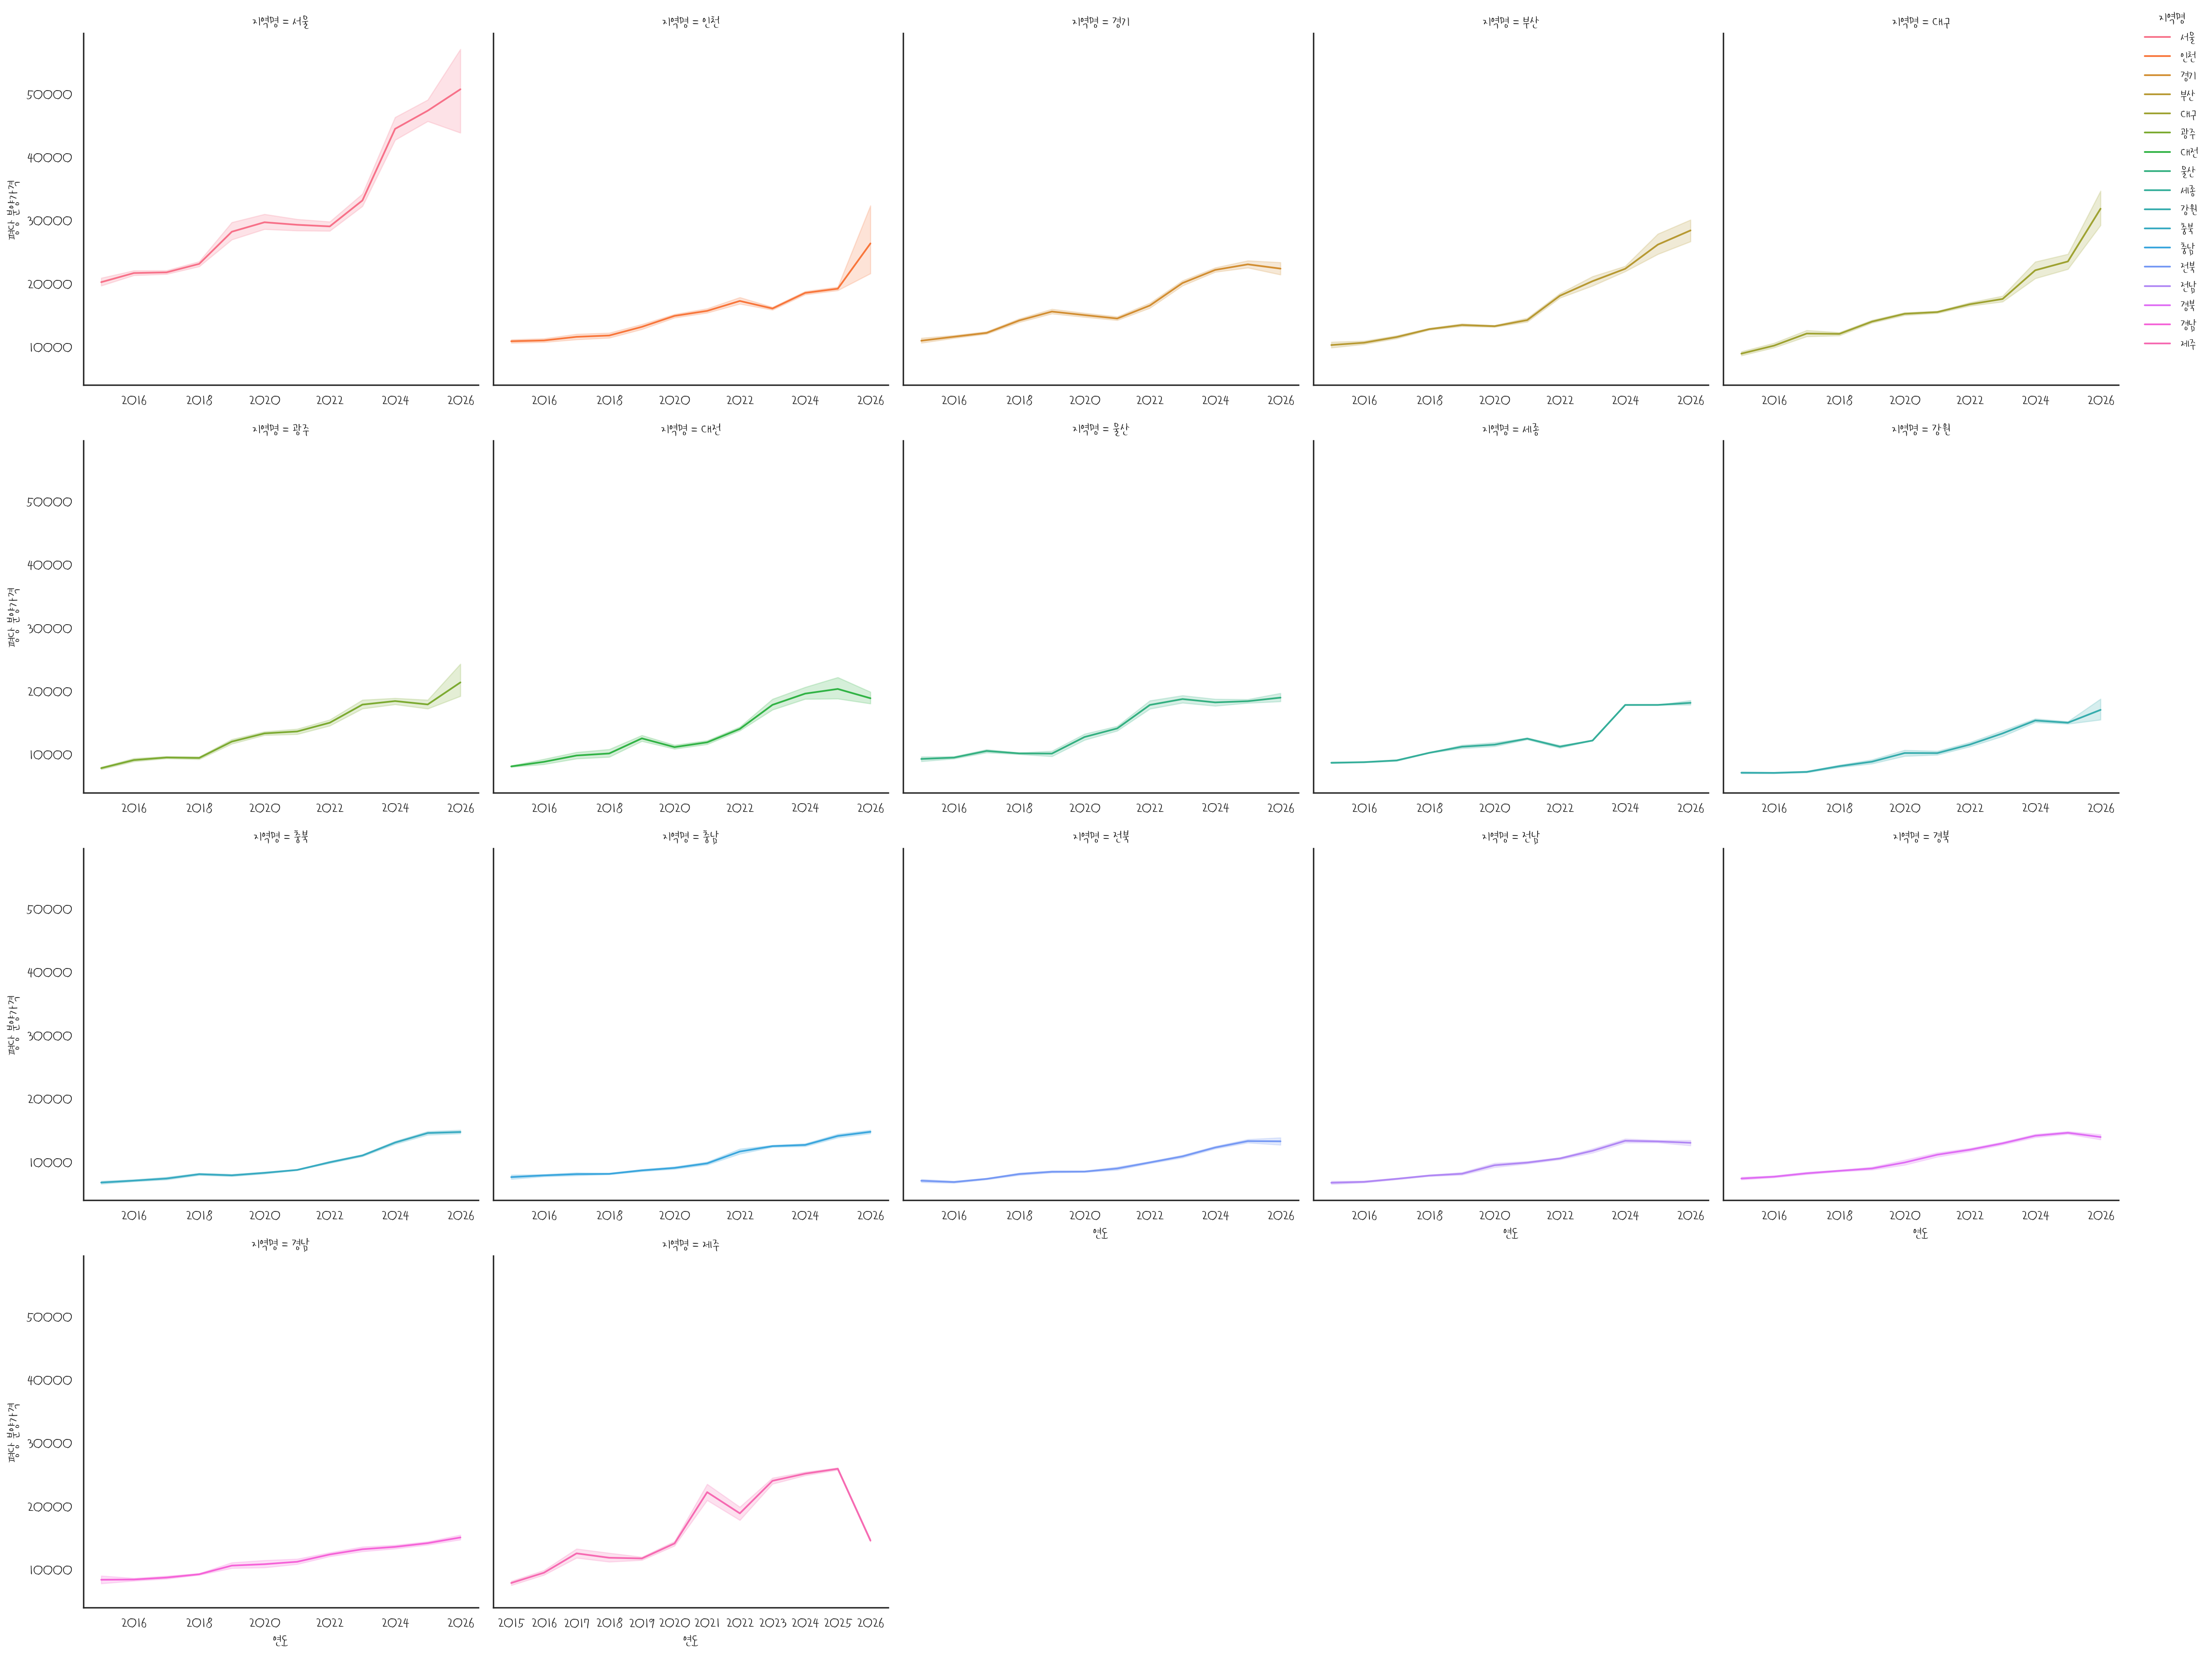

In [214]:
r = df_last.groupby('연도')['평당 분양가격'].mean().sort_values()
ax = sns.relplot(data=df_last, x='연도', y='평당 분양가격', kind='line', hue='지역명', col='지역명',  col_wrap=5, facet_kws={'sharex':False})
plt.xticks(range(2015,2027))
plt.tight_layout()
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.show()

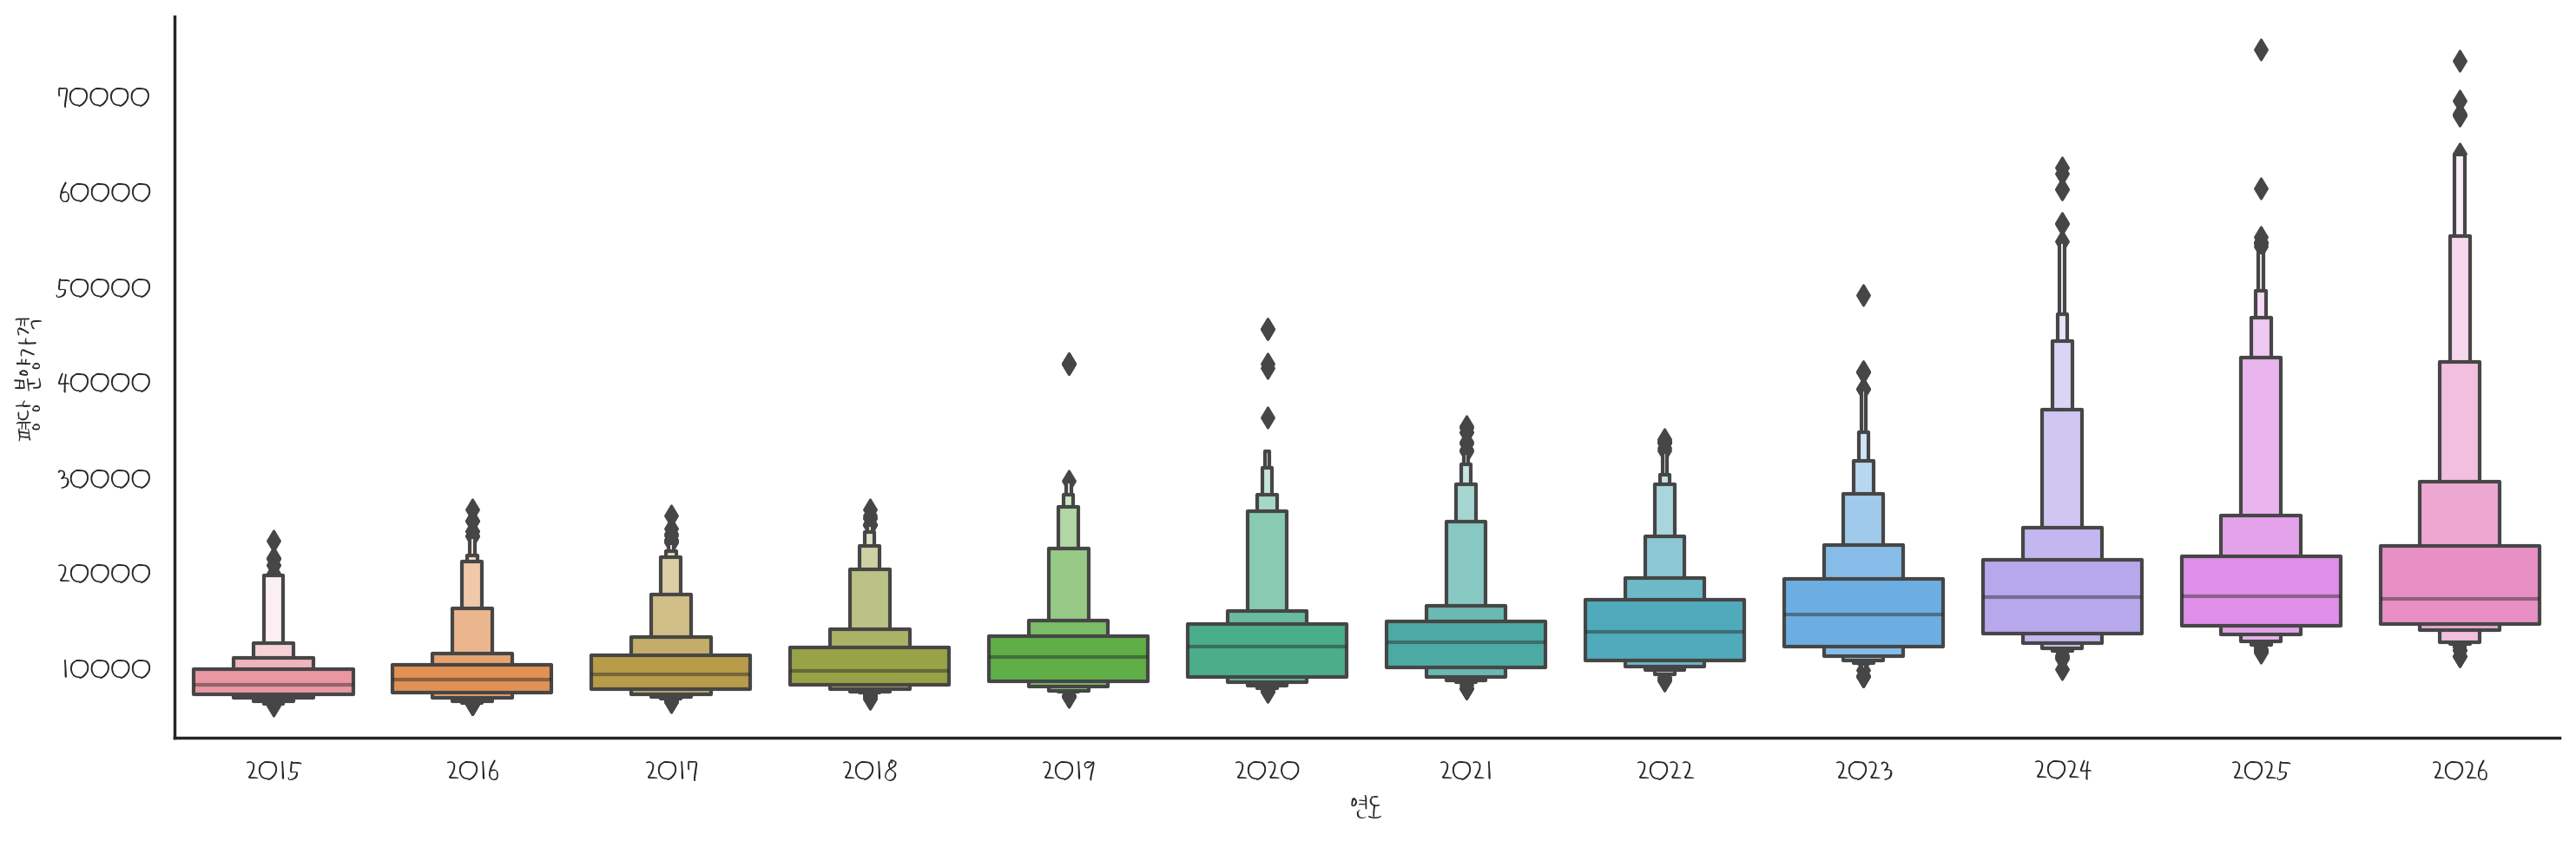

In [231]:
r = df_last.groupby('연도')['평당 분양가격'].mean().sort_values()
ax = sns.catplot(data=df_last, x='연도', y='평당 분양가격', kind='boxen')
ax.fig.set_size_inches(15,5)
plt.tight_layout()
plt.show()

CPU times: total: 1.64 s
Wall time: 1.66 s


<Axes: xlabel='연도', ylabel='평당 분양가격'>

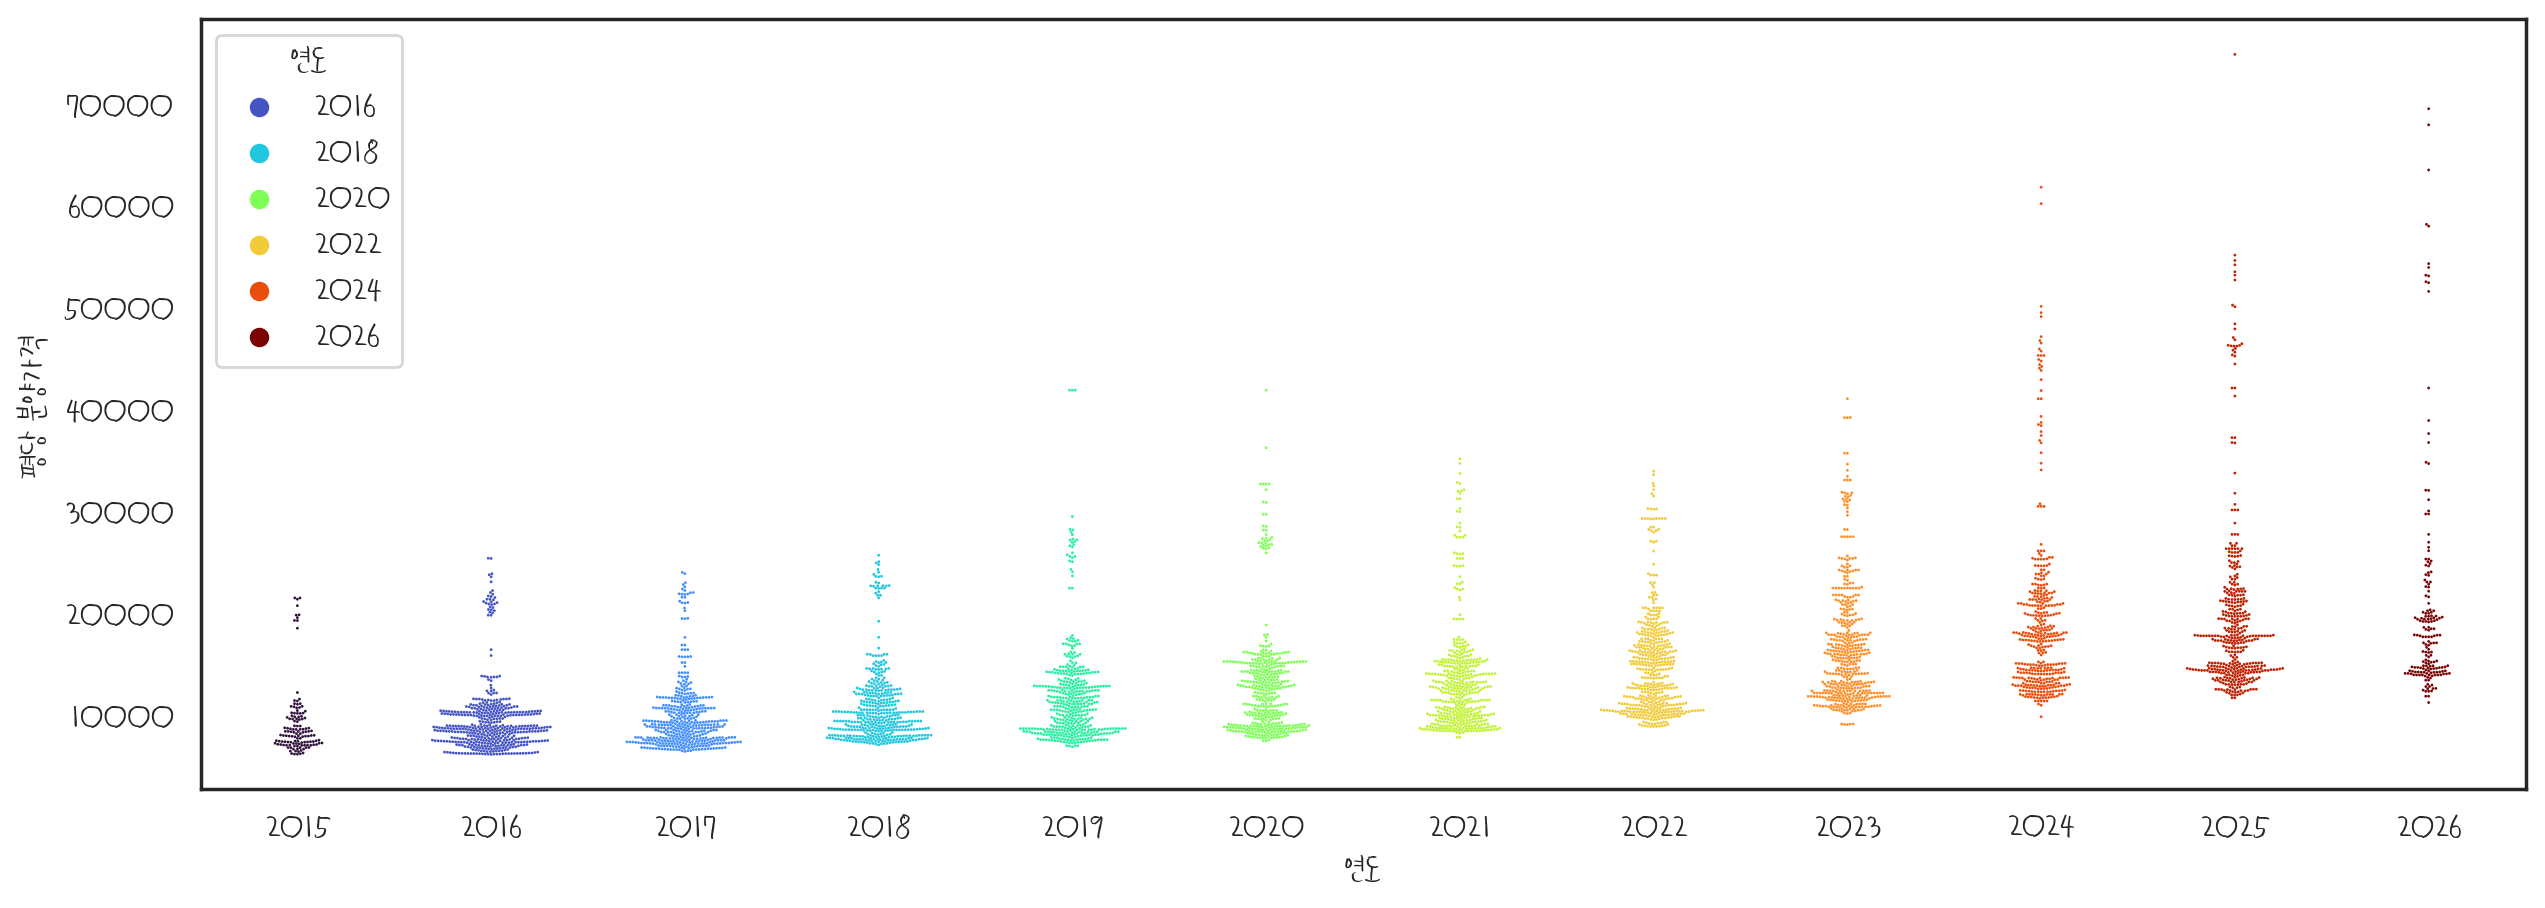

In [257]:
%%time
# df_last.sample(frac=0.05) - fraction 비율
plt.figure(figsize=(15, 5))
sns.swarmplot(data=df_last.sample(frac=0.5), x='연도', y='평당 분양가격', size=1, hue='연도', palette='turbo')

https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot : 범례사용(교안 20page)

# 10. 구조가 다른 df_first와 df_last를 연결 후 분석
## (1) concat

```
- new_first :df_first를 [지역명, 연도, 월, 평당분양가격]으로 변환
- new_last : df_last를 [지역명, 연도, 월, 평당분양가격]으로 변환
                (전용면적이 모든면적인 행만 추출후, 전용면적 열을 삭제)
```

In [289]:
new_first = df_first.melt(id_vars='지역',
                         var_name='연도월',
                         value_name='평당분양가격')
new_first.head()

,지역,연도월,평당분양가격
0,서울,2013년12월,18189
1,부산,2013년12월,8111
2,대구,2013년12월,8080
3,인천,2013년12월,10204
4,광주,2013년12월,6098


In [290]:
new_first['연도'] = new_first['연도월'].map(lambda datestr : int(datestr[:4]))
new_first['월'] = new_first['연도월'].map(lambda datestr : int(datestr[5:-1]))
new_first.head()

,지역,연도월,평당분양가격,연도,월
0,서울,2013년12월,18189,2013,12
1,부산,2013년12월,8111,2013,12
2,대구,2013년12월,8080,2013,12
3,인천,2013년12월,10204,2013,12
4,광주,2013년12월,6098,2013,12


In [291]:
new_first.rename(columns={'지역':'지역명'}, inplace = True)

In [292]:
new_first = new_first.drop('연도월', axis=1)
new_first.head()

,지역명,평당분양가격,연도,월
0,서울,18189,2013,12
1,부산,8111,2013,12
2,대구,8080,2013,12
3,인천,10204,2013,12
4,광주,6098,2013,12


In [293]:
new_first.rename(columns={'평당분양가격':'평당 분양가격'}, inplace = True)
new_first.head()

,지역명,평당 분양가격,연도,월
0,서울,18189,2013,12
1,부산,8111,2013,12
2,대구,8080,2013,12
3,인천,10204,2013,12
4,광주,6098,2013,12


In [294]:
new_last = df_last[df_last['전용면적']=='모든면적']
new_last = new_last.drop('전용면적', axis=1)
new_last.head(1)

,지역명,연도,월,평당 분양가격
0,서울,2015,10,19275.3


In [295]:
df_all = pd.concat([new_first,new_last]).sort_values(by=['연도', '월']).reset_index(drop=True)

In [298]:
df_all.iloc[::500]

,지역명,평당 분양가격,연도,월
0,서울,18189.0,2013,12
500,울산,10127.7,2016,6
1000,경북,8847.3,2018,11
1500,대구,15519.9,2021,5
2000,충남,11922.9,2023,10
2500,인천,21090.3,2026,4


In [299]:
df_all.shape

(2533, 4)

In [301]:
df_all.to_csv('data/df_all.csv', index=False) # 전처리 단계 백업

In [312]:
df_all = pd.read_csv('data/df_all.csv')

## (2) 결측치 대체(연도별, 지역별 중위값)

In [313]:
df_all.isna().sum()

지역명         0
평당 분양가격    35
연도          0
월           0
dtype: int64

In [314]:
fillnadf = df_all.groupby(['연도', '지역명'])['평당 분양가격'].median().unstack()
fillnadf

지역명,강원,경기,경남,경북,광주,대구,대전,부산,서울,세종,울산,인천,전남,전북,제주,충남,충북
연도,,,,,,,,,,,,,,,,,
2013,6230.00,10855.00,6473.00,6168.00,6098.00,8080.00,8321.00,8111.00,18189.00,7601.0,8090.00,10204.00,5678.00,6282.00,7674.00,6365.00,6589.00
2014,6350.00,10449.00,6611.50,6555.00,7617.00,8317.00,8327.00,9233.00,19070.50,8067.0,8153.00,10018.00,5716.00,6335.00,7900.00,6724.50,6593.50
2015,6986.00,10518.00,7665.00,7006.00,7914.00,8542.00,8079.00,9515.00,19275.30,8669.0,9192.00,10443.00,6243.00,6583.00,7365.60,6975.00,6705.60
2016,6964.65,11342.10,7865.55,7385.40,8987.55,10335.60,8380.35,10414.80,20654.70,8860.5,10127.70,10531.95,6491.10,6369.00,9329.10,7377.15,6801.30
2017,7057.05,11919.60,8052.00,7835.85,9551.85,11231.55,9035.40,11851.95,21402.15,9018.9,11488.95,10875.15,7114.80,7222.05,10885.05,7448.10,6765.00
2018,7669.20,13099.35,8898.45,8667.45,9678.90,12178.65,9807.60,12926.10,22567.05,10388.4,10312.50,11233.20,7774.80,7652.70,11649.00,8030.55,7870.50
2019,8221.95,14487.00,9791.10,8723.55,12071.40,13963.95,11866.80,13061.40,26428.05,11411.4,10362.00,12827.10,7920.00,8146.05,12561.45,8598.15,7570.20
2020,9271.35,14331.90,10263.00,9929.70,12624.15,15302.10,11030.25,13266.00,26769.60,11355.3,12581.25,14648.70,8571.75,8225.25,15130.50,8863.80,7924.95
2021,9607.95,14173.50,10523.70,10338.90,14127.30,15528.15,12196.80,14460.60,29769.30,12533.4,14256.00,14950.65,9857.10,8834.10,23756.70,9306.00,8677.35


In [315]:
def fill_median(row):
    row = row.copy()
    if pd.isna(row['평당 분양가격']):
        year = row['연도']
        locate = row['지역명']
        row['평당 분양가격'] = fillnadf.loc[year, locate]
    return row

fill_median(df_all.loc[1010])

지역명             울산
평당 분양가격    10312.5
연도            2018
월               12
Name: 1010, dtype: object

In [317]:
df = df_all.apply(fill_median, axis=1)
df.isna().sum()

지역명        0
평당 분양가격    0
연도         0
월          0
dtype: int64

## (3) df.csv파일로 출력

In [318]:
df.to_csv('data/df(최종).csv', index=False) # 전처리 단계 백업

In [319]:
df = pd.read_csv('data/df(최종).csv')

## (4) 7절부터 9절까지 분석을 한다(전용면적별 분석은 불가)

- 지역명별 데이터 갯수는 결측치가 없어서 동일(groupby나 pivot_table등으로 확인)
- 지역명별 평당분양가격(groupby, pivot_table, plot, seaborn 연습)
- 연도별 지역명별 평당분양가격(groupby, pivot_table, plot, seaborn 연습)

### ① 지역명별 데이터 행 갯수 : 결과가 1차원 시리즈

### ② 지역별 평당분양가격(평균, 최대값, ... 요약통계량)

In [ ]:
# 지역명당 평당분양가격 시각화(lineplot과 matplotlib의 bar, sns의 barplot)

### ③ 연도별 평당분양가격(평균)

In [ ]:
# 연도별 평당분양가격 시각화(lineplot과 matplotlib의 bar, sns의 barplot)

### ④ 연도, 지역별 평당분양가격(평균)

In [ ]:
# 연도별, 지역별 평당분양가격 시각화(heatmap)

In [ ]:
# 년도별 평균 평당분양가격의 추이

In [ ]:
# 위의 그래프가 겹쳐서 작 보이지 않아 분리

In [ ]:
# 관계형 그래프의 서브플롯을 그리는 함수는 relplot
# 범주형 그래프의 서브플롯을 그리는 함수는 catplot

In [ ]:
# 연도별 평당분양가격의 사분위수


In [ ]:
# 연도별 평당분양가격의 사분위수(분포포함 boxenplot)


In [ ]:
# 연도별 평당분양가격의 사분위수(분포포함 violinplot)


In [ ]:
# 연도에 따른 평당분양가격을 회귀식으로 시각화


In [ ]:
# swarmplot은 많은 데이터를 그리기에는 시간이 많이 걸려 5%만 sampling후 그릴 것을 추천
# 연도별 평당분양가격 산점도
 

In [ ]:
# 분양가격을 hist
